In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
checkpoint_path = "/fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints"

In [3]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
checkpoint_base = Path(checkpoint_path)

In [5]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (30, 8)

In [6]:
# Define model order and colors
# Order: baseline first, then pairs of (regular, ancestor) for each model
MODEL_ORDER = [
    'baseline', 
    'hardatt', 'ancestor_hardatt',
    'softatt', 'ancestor_softatt',
    'gcn', 'ancestor_gcn',
    'gcn_and_hartatt', 'ancestor_gcn_and_hartatt',
    'gcn_and_softatt', 'ancestor_gcn_and_softatt'
]

MODEL_COLORS = {
    'baseline': '#440154',
    'hardatt': '#31688e',
    'ancestor_hardatt': '#5a9bc4',  # Lighter version of hardatt
    'softatt': '#35b779',
    'ancestor_softatt': '#6dcd9f',  # Lighter version of softatt
    'gcn': '#fde724',
    'ancestor_gcn': '#fee761',  # Lighter version of gcn
    'gcn_and_hartatt': '#90d743',
    'ancestor_gcn_and_hartatt': '#ade577',  # Lighter version
    'gcn_and_softatt': '#21918c',
    'ancestor_gcn_and_softatt': '#46c0b6'  # Lighter version
}

def load_benchmark_results(checkpoint_base, pattern, eval_step=None):
    """Load all benchmark JSON files matching the given pattern.
    
    Now supports loading from lingaus_eval_stepXXXXX directories with path variants:
    - base: standard causal graph
    - path_YT: Y -> T path variant
    - path_TY: T -> Y path variant  
    - path_independent_TY: T and Y independent variant
    
    Parameters
    ----------
    checkpoint_base : Path
        Base directory containing checkpoint folders
    pattern : str
        Glob pattern to match checkpoint directories
    eval_step : str or None
        If provided, load from lingaus_eval_step{eval_step} directory instead of lingaus_final
        
    Returns
    -------
    dict
        Nested dictionary: {checkpoint_name: {variant: {node_count: metrics}}}
        where variant is one of: 'base', 'path_YT', 'path_TY', 'path_independent_TY'
    """
    results_dict = {}
    
    for ckpt_dir in sorted(checkpoint_base.glob(pattern)):
        checkpoint_results = {}
        
        # Determine which directory to load from
        if eval_step is not None:
            results_dir = ckpt_dir / f"lingaus_eval_step{eval_step}"
        else:
            results_dir = ckpt_dir / "lingaus_final"
        
        if not results_dir.exists():
            print(f"Missing results dir: {results_dir}")
            continue
        
        # Check for new format with multiple variant files
        has_variant_files = False
        variant_files = {}
        
        for node_count in [2, 5, 10, 20, 35, 50]:
            # Check for base variant (no suffix)
            base_file = results_dir / f"aggregated_{node_count}nodes.json"
            if base_file.exists():
                has_variant_files = True
                if 'base' not in variant_files:
                    variant_files['base'] = []
                variant_files['base'].append((node_count, base_file))
            
            # Check for path variants
            for variant_suffix in ['path_YT', 'path_TY', 'path_independent_TY']:
                variant_file = results_dir / f"aggregated_{node_count}nodes_{variant_suffix}.json"
                if variant_file.exists():
                    has_variant_files = True
                    if variant_suffix not in variant_files:
                        variant_files[variant_suffix] = []
                    variant_files[variant_suffix].append((node_count, variant_file))
        
        if has_variant_files:
            # New format: load from individual variant files
            for variant, files in variant_files.items():
                variant_data = {}
                for node_count, filepath in files:
                    try:
                        with open(filepath, 'r') as f:
                            data = json.load(f)
                            variant_data[str(node_count)] = data
                    except Exception as e:
                        print(f"Error loading {filepath}: {e}")
                checkpoint_results[variant] = variant_data
            
            if checkpoint_results:
                results_dict[ckpt_dir.name] = checkpoint_results
                print(f"Loaded: {ckpt_dir.name} ({len(checkpoint_results)} variants)")
        else:
            # Old format: single lingaus_benchmark_final.json file
            json_path = results_dir / "lingaus_benchmark_final.json"
            if json_path.exists():
                try:
                    with open(json_path, 'r') as f:
                        data = json.load(f)
                        # Wrap in 'base' variant for consistency
                        checkpoint_results['base'] = data
                        results_dict[ckpt_dir.name] = checkpoint_results
                        print(f"Loaded: {ckpt_dir.name} (legacy format)")
                except Exception as e:
                    print(f"Error loading {json_path}: {e}")
            else:
                print(f"Missing JSON in: {ckpt_dir.name}")
    
    print(f"\nTotal loaded: {len(results_dict)} results")
    return results_dict


def extract_model_name(checkpoint_name):
    """Extract model name from checkpoint directory name."""
    parts = checkpoint_name.split('_')
    model_name_parts = []
    is_ancestor = False
    
    # Handle both "benchmarked" and "ancestor" patterns
    # For benchmarked: lingaus_5node_benchmarked_gcn_16694420.0
    # For ancestor: lingaus_ancestor_5node_gcn_16703127.0
    
    # Check if this is an ancestor model
    if "ancestor" in parts:
        is_ancestor = True
    
    start_collecting = False
    for i, part in enumerate(parts):
        # Start collecting after "benchmarked" keyword
        if part == "benchmarked":
            start_collecting = True
            continue
        
        # For ancestor pattern: start collecting after "Xnode" (e.g., "5node")
        if "node" in part and part.replace("node", "").isdigit():
            start_collecting = True
            continue
        
        # Collect parts that are not PIDs (numbers with dots)
        if start_collecting and not part.replace('.', '').replace('-', '').isdigit():
            model_name_parts.append(part)
    
    model_name = '_'.join(model_name_parts) if model_name_parts else 'unknown'
    
    # Add "ancestor_" prefix if this is an ancestor model
    if is_ancestor and model_name != 'unknown':
        model_name = f'ancestor_{model_name}'
    
    return model_name


def create_dataframe(results_dict, include_variants=True):
    """Convert results dictionary to pandas DataFrame.
    
    Parameters
    ----------
    results_dict : dict
        Nested dictionary from load_benchmark_results
    include_variants : bool
        If True, include variant information in the dataframe
        
    Returns
    -------
    pd.DataFrame
        DataFrame with columns: model, variant, node_count, and metric columns
    """
    data_rows = []
    
    for checkpoint_name, checkpoint_data in results_dict.items():
        model_name = extract_model_name(checkpoint_name)
        
        # Iterate through variants
        for variant, variant_data in checkpoint_data.items():
            # Iterate through each node count
            for node_count, node_data in variant_data.items():
                row = {
                    'model': model_name,
                    'variant': variant,
                    'node_count': int(node_count),
                }
                
                # Extract metrics (mse, r2, nll, etc.)
                for metric_name, metric_values in node_data.items():
                    if metric_name != 'metadata' and isinstance(metric_values, dict):
                        for stat_name, stat_value in metric_values.items():
                            if isinstance(stat_value, (int, float)):
                                row[f"{metric_name}_{stat_name}"] = stat_value
                
                data_rows.append(row)
    
    df = pd.DataFrame(data_rows)
    
    # Drop rows where key metrics are NaN (incomplete runs)
    print(f"Original shape: {df.shape}")
    df = df.dropna(subset=['mse_mean', 'r2_mean', 'nll_mean'])
    print(f"After dropping NaN rows: {df.shape}")
    
    # Apply consistent model order
    df['model'] = pd.Categorical(df['model'], categories=MODEL_ORDER, ordered=True)
    
    return df


def plot_metrics_vs_nodes(df, title_suffix="", variant_filter=None):
    """Create line plots showing how metrics change with node count.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with benchmark results
    title_suffix : str
        Suffix to add to plot title
    variant_filter : str or None
        If provided, only plot this variant (e.g., 'base', 'path_YT')
        If None, create separate subplot for each variant
    """
    # Filter by variant if specified
    if variant_filter is not None:
        df = df[df['variant'] == variant_filter].copy()
        variants = [variant_filter]
    else:
        variants = sorted(df['variant'].unique())
    
    metrics_to_plot = ['mse', 'r2', 'nll']
    metric_titles = ['MSE vs Node Count', 'R² vs Node Count', 'NLL vs Node Count']
    
    n_variants = len(variants)
    fig, axes = plt.subplots(n_variants, len(metrics_to_plot), 
                            figsize=(18, 5 * n_variants))
    
    # Handle single variant case (axes won't be 2D)
    if n_variants == 1:
        axes = axes.reshape(1, -1)
    
    for variant_idx, variant in enumerate(variants):
        variant_data = df[df['variant'] == variant].copy()
        
        for metric_idx, (metric, metric_title) in enumerate(zip(metrics_to_plot, metric_titles)):
            ax = axes[variant_idx, metric_idx]
            
            metric_col = f'{metric}_mean'
            ci_lower_col = f'{metric}_mean_ci_lower'
            ci_upper_col = f'{metric}_mean_ci_upper'
            
            # Plot each model
            for model in MODEL_ORDER:
                model_data = variant_data[variant_data['model'] == model].copy()
                
                if len(model_data) == 0:
                    continue
                
                model_data = model_data.sort_values('node_count')
                node_counts = model_data['node_count'].values
                
                if metric_col in model_data.columns:
                    metric_vals = model_data[metric_col].values
                    
                    # Plot line
                    color = MODEL_COLORS.get(str(model), '#808080')
                    ax.plot(node_counts, metric_vals, marker='o', label=str(model), 
                           color=color, linewidth=2, markersize=8)
                    
                    # Add confidence interval shading if available
                    if ci_lower_col in model_data.columns and ci_upper_col in model_data.columns:
                        ci_lower = model_data[ci_lower_col].values
                        ci_upper = model_data[ci_upper_col].values
                        ax.fill_between(node_counts, ci_lower, ci_upper, 
                                      alpha=0.2, color=color)
            
            ax.set_xlabel('Number of Nodes', fontsize=11, fontweight='bold')
            if metric_idx == 0:
                ax.set_ylabel(f'{variant}\n\nMetric Value', fontsize=11, fontweight='bold')
            else:
                ax.set_ylabel('Metric Value', fontsize=11, fontweight='bold')
            
            if variant_idx == 0:
                ax.set_title(metric_title, fontsize=12, fontweight='bold')
            
            ax.legend(loc='best', fontsize=9, framealpha=0.9)
            ax.grid(True, alpha=0.3)
            ax.set_xticks(sorted(variant_data['node_count'].unique()))
    
    main_title = 'Metrics vs Node Count (95% CI Shaded)'
    if title_suffix:
        main_title = f'{main_title} - {title_suffix}'
    if variant_filter:
        main_title = f'{main_title} [{variant_filter}]'
    plt.suptitle(main_title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_bar_comparison(df, node_counts_to_compare=None, title_suffix="", variant_filter=None):
    """Create bar charts comparing models at specific node counts.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with benchmark results
    node_counts_to_compare : list or None
        List of node counts to plot
    title_suffix : str
        Suffix to add to plot title
    variant_filter : str or None
        If provided, only plot this variant (e.g., 'base', 'path_YT')
        If None, plot all variants with grouped bars
    """
    if node_counts_to_compare is None:
        node_counts_to_compare = sorted(df['node_count'].unique())
    
    # Filter by variant if specified
    if variant_filter is not None:
        df = df[df['variant'] == variant_filter].copy()
        variants = [variant_filter]
    else:
        variants = sorted(df['variant'].unique())
    
    metrics_to_plot = ['mse', 'r2', 'nll']
    metric_titles = ['MSE', 'R²', 'NLL']
    
    # Adjust figure width based on number of variants
    fig_width = 20 if len(variants) == 1 else 30
    fig, axes = plt.subplots(len(metrics_to_plot), len(node_counts_to_compare), 
                            figsize=(fig_width, 12))
    
    # Variant colors for grouped bars
    variant_colors_map = {
        'base': 0.0,
        'path_YT': 0.15,
        'path_TY': 0.30,
        'path_independent_TY': 0.45
    }
    
    for metric_idx, (metric, metric_title) in enumerate(zip(metrics_to_plot, metric_titles)):
        for node_idx, node_count in enumerate(node_counts_to_compare):
            ax = axes[metric_idx, node_idx]
            
            # Filter data for this node count
            node_data = df[df['node_count'] == node_count].copy()
            
            if len(node_data) == 0:
                ax.text(0.5, 0.5, f'No data', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{node_count} Nodes')
                continue
            
            # Sort by model order
            node_data = node_data.sort_values(['model', 'variant'])
            
            # Get unique models
            models = node_data['model'].unique()
            n_models = len(models)
            n_variants = len(variants)
            
            # Calculate bar positions for grouped bars
            bar_width = 0.8 / n_variants if n_variants > 1 else 0.8
            
            metric_col = f'{metric}_mean'
            if metric_col not in node_data.columns:
                continue
            
            # Store baseline value for reference line
            baseline_val = None
            
            # Plot bars grouped by model and variant
            for variant_idx, variant in enumerate(variants):
                variant_data = node_data[node_data['variant'] == variant]
                
                if len(variant_data) == 0:
                    continue
                
                x_positions = []
                metric_vals = []
                yerr_lower_list = []
                yerr_upper_list = []
                colors = []
                
                for model_idx, model in enumerate(models):
                    model_variant_data = variant_data[variant_data['model'] == model]
                    
                    if len(model_variant_data) == 0:
                        continue
                    
                    # Calculate x position for this bar
                    if n_variants > 1:
                        x_pos = model_idx + (variant_idx - n_variants/2 + 0.5) * bar_width
                    else:
                        x_pos = model_idx
                    
                    x_positions.append(x_pos)
                    
                    # Get metric value
                    val = model_variant_data[metric_col].values[0]
                    metric_vals.append(val)
                    
                    # Store baseline value
                    if model == 'baseline' and variant == 'base':
                        baseline_val = val
                    
                    # Calculate error bars from 95% CI
                    ci_lower_col = f'{metric}_mean_ci_lower'
                    ci_upper_col = f'{metric}_mean_ci_upper'
                    
                    if ci_lower_col in model_variant_data.columns and ci_upper_col in model_variant_data.columns:
                        ci_lower = model_variant_data[ci_lower_col].values[0]
                        ci_upper = model_variant_data[ci_upper_col].values[0]
                        yerr_lower_list.append(val - ci_lower)
                        yerr_upper_list.append(ci_upper - val)
                    else:
                        yerr_lower_list.append(0)
                        yerr_upper_list.append(0)
                    
                    # Get base color for model and adjust brightness for variant
                    base_color = MODEL_COLORS.get(str(model), '#808080')
                    # Convert hex to RGB, adjust brightness, convert back
                    import matplotlib.colors as mcolors
                    rgb = mcolors.hex2color(base_color)
                    brightness_adjust = variant_colors_map.get(variant, 0.0)
                    adjusted_rgb = tuple(min(1.0, c + brightness_adjust) for c in rgb)
                    colors.append(adjusted_rgb)
                
                if x_positions:
                    yerr = np.array([yerr_lower_list, yerr_upper_list])
                    
                    bars = ax.bar(x_positions, metric_vals, bar_width, 
                                yerr=yerr, capsize=3, alpha=0.7,
                                edgecolor='black', linewidth=1.0,
                                label=variant if n_variants > 1 else None)
                    
                    # Color bars
                    for bar, color in zip(bars, colors):
                        bar.set_facecolor(color)
                    
                    # Add value labels
                    for x, val, yerr_u in zip(x_positions, metric_vals, yerr_upper_list):
                        label_y = val + yerr_u
                        ax.text(x, label_y, f'{val:.3f}', ha='center', va='bottom', 
                               fontsize=6, rotation=0)
            
            # Add horizontal line at baseline level
            if baseline_val is not None:
                ax.axhline(y=baseline_val, color='gray', linestyle='--', linewidth=2, alpha=0.7, zorder=0)
            
            # Set x-axis labels
            ax.set_xticks(range(n_models))
            ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
            
            if node_idx == 0:
                ax.set_ylabel(metric_title, fontsize=11, fontweight='bold')
            
            if metric_idx == 0:
                title = f'{node_count} Nodes'
                if n_variants > 1 and node_idx == len(node_counts_to_compare) - 1:
                    ax.legend(loc='upper right', fontsize=8)
                ax.set_title(title, fontsize=11, fontweight='bold')
            
            ax.grid(axis='y', alpha=0.3)
    
    main_title = 'Model Performance Comparison Across Node Counts (95% CI)'
    if title_suffix:
        main_title = f'{main_title} - {title_suffix}'
    if variant_filter:
        main_title = f'{main_title} [{variant_filter}]'
    plt.suptitle(main_title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


def plot_bar_comparison_separate_variants(df, node_counts_to_compare=None, title_suffix=""):
    """Create separate bar chart figures for each variant.
    
    This function creates completely independent plots for each variant (base, path_YT, 
    path_TY, path_independent_TY), making it easier to focus on model comparisons within 
    each causal structure.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with benchmark results
    node_counts_to_compare : list or None
        List of node counts to plot
    title_suffix : str
        Suffix to add to plot titles
    """
    if node_counts_to_compare is None:
        node_counts_to_compare = sorted(df['node_count'].unique())
    
    variants = sorted(df['variant'].unique())
    metrics_to_plot = ['mse', 'r2', 'nll']
    metric_titles = ['MSE', 'R²', 'NLL']
    
    # Variant display names
    variant_display_names = {
        'base': 'Base Causal Structure',
        'path_YT': 'Y → T Path',
        'path_TY': 'T → Y Path',
        'path_independent_TY': 'T ⊥ Y (Independent)'
    }
    
    # Create separate figure for each variant
    for variant in variants:
        variant_data = df[df['variant'] == variant].copy()
        
        if len(variant_data) == 0:
            print(f"No data for variant: {variant}")
            continue
        
        fig, axes = plt.subplots(len(metrics_to_plot), len(node_counts_to_compare), 
                                figsize=(20, 12))
        
        for metric_idx, (metric, metric_title) in enumerate(zip(metrics_to_plot, metric_titles)):
            for node_idx, node_count in enumerate(node_counts_to_compare):
                ax = axes[metric_idx, node_idx]
                
                # Filter data for this node count
                node_data = variant_data[variant_data['node_count'] == node_count].copy()
                
                if len(node_data) == 0:
                    ax.text(0.5, 0.5, f'No data', 
                           ha='center', va='center', transform=ax.transAxes)
                    ax.set_title(f'{node_count} Nodes')
                    continue
                
                # Sort by model order
                node_data = node_data.sort_values('model')
                
                # Get unique models
                models = node_data['model'].unique()
                n_models = len(models)
                
                metric_col = f'{metric}_mean'
                if metric_col not in node_data.columns:
                    continue
                
                # Store baseline value for reference line
                baseline_val = None
                
                x_positions = []
                metric_vals = []
                yerr_lower_list = []
                yerr_upper_list = []
                colors = []
                
                for model_idx, model in enumerate(models):
                    model_data = node_data[node_data['model'] == model]
                    
                    if len(model_data) == 0:
                        continue
                    
                    x_positions.append(model_idx)
                    
                    # Get metric value
                    val = model_data[metric_col].values[0]
                    metric_vals.append(val)
                    
                    # Store baseline value
                    if model == 'baseline':
                        baseline_val = val
                    
                    # Calculate error bars from 95% CI
                    ci_lower_col = f'{metric}_mean_ci_lower'
                    ci_upper_col = f'{metric}_mean_ci_upper'
                    
                    if ci_lower_col in model_data.columns and ci_upper_col in model_data.columns:
                        ci_lower = model_data[ci_lower_col].values[0]
                        ci_upper = model_data[ci_upper_col].values[0]
                        yerr_lower_list.append(val - ci_lower)
                        yerr_upper_list.append(ci_upper - val)
                    else:
                        yerr_lower_list.append(0)
                        yerr_upper_list.append(0)
                    
                    # Get color for model
                    colors.append(MODEL_COLORS.get(str(model), '#808080'))
                
                if x_positions:
                    yerr = np.array([yerr_lower_list, yerr_upper_list])
                    
                    bars = ax.bar(x_positions, metric_vals, 0.8, 
                                yerr=yerr, capsize=3, alpha=0.7,
                                edgecolor='black', linewidth=1.0)
                    
                    # Color bars
                    for bar, color in zip(bars, colors):
                        bar.set_facecolor(color)
                    
                    # Add value labels
                    for x, val, yerr_u in zip(x_positions, metric_vals, yerr_upper_list):
                        label_y = val + yerr_u
                        ax.text(x, label_y, f'{val:.3f}', ha='center', va='bottom', 
                               fontsize=7, rotation=0)
                
                # Add horizontal line at baseline level
                if baseline_val is not None:
                    ax.axhline(y=baseline_val, color='gray', linestyle='--', 
                             linewidth=2, alpha=0.7, zorder=0)
                
                # Set x-axis labels
                ax.set_xticks(range(n_models))
                ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
                
                if node_idx == 0:
                    ax.set_ylabel(metric_title, fontsize=11, fontweight='bold')
                
                if metric_idx == 0:
                    ax.set_title(f'{node_count} Nodes', fontsize=11, fontweight='bold')
                
                ax.grid(axis='y', alpha=0.3)
        
        # Create main title with variant info
        variant_name = variant_display_names.get(variant, variant)
        main_title = f'Model Performance: {variant_name} (95% CI)'
        if title_suffix:
            main_title = f'{main_title} - {title_suffix}'
        plt.suptitle(main_title, fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()


def plot_box_comparison(df, node_counts_to_compare=None, title_suffix="", variant_filter=None):
    """Create box plots comparing models at specific node counts.
    
    Box plots show the distribution of performance metrics using confidence intervals
    to create synthetic quartiles. This provides an alternative visualization to bar charts
    that better represents uncertainty.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with benchmark results
    node_counts_to_compare : list or None
        List of node counts to plot
    title_suffix : str
        Suffix to add to plot title
    variant_filter : str or None
        If provided, only plot this variant (e.g., 'base', 'path_YT')
        If None, plot all variants with grouped boxes
    """
    if node_counts_to_compare is None:
        node_counts_to_compare = sorted(df['node_count'].unique())
    
    # Filter by variant if specified
    if variant_filter is not None:
        df = df[df['variant'] == variant_filter].copy()
        variants = [variant_filter]
    else:
        variants = sorted(df['variant'].unique())
    
    metrics_to_plot = ['mse', 'r2', 'nll']
    metric_titles = ['MSE', 'R²', 'NLL']
    
    # Adjust figure width based on number of variants
    fig_width = 20 if len(variants) == 1 else 30
    fig, axes = plt.subplots(len(metrics_to_plot), len(node_counts_to_compare), 
                            figsize=(fig_width, 12))
    
    for metric_idx, (metric, metric_title) in enumerate(zip(metrics_to_plot, metric_titles)):
        for node_idx, node_count in enumerate(node_counts_to_compare):
            ax = axes[metric_idx, node_idx]
            
            # Filter data for this node count
            node_data = df[df['node_count'] == node_count].copy()
            
            if len(node_data) == 0:
                ax.text(0.5, 0.5, f'No data', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{node_count} Nodes')
                continue
            
            # Sort by model order
            node_data = node_data.sort_values(['model', 'variant'])
            
            # Get unique models
            models = node_data['model'].unique()
            n_models = len(models)
            n_variants = len(variants)
            
            # Calculate box positions for grouped boxes
            box_width = 0.8 / n_variants if n_variants > 1 else 0.6
            
            metric_col = f'{metric}_mean'
            if metric_col not in node_data.columns:
                continue
            
            # Store baseline value for reference line
            baseline_val = None
            
            # Plot boxes grouped by model and variant
            for variant_idx, variant in enumerate(variants):
                variant_data = node_data[node_data['variant'] == variant]
                
                if len(variant_data) == 0:
                    continue
                
                box_data = []
                positions = []
                colors = []
                mean_values = []
                
                for model_idx, model in enumerate(models):
                    model_variant_data = variant_data[variant_data['model'] == model]
                    
                    if len(model_variant_data) == 0:
                        continue
                    
                    # Calculate position for this box
                    if n_variants > 1:
                        pos = model_idx + (variant_idx - n_variants/2 + 0.5) * box_width
                    else:
                        pos = model_idx
                    
                    positions.append(pos)
                    
                    # Get metric statistics
                    mean_val = model_variant_data[metric_col].values[0]
                    mean_values.append(mean_val)
                    
                    # Store baseline value
                    if model == 'baseline' and variant == 'base':
                        baseline_val = mean_val
                    
                    # Create synthetic distribution from CI bounds
                    ci_lower_col = f'{metric}_mean_ci_lower'
                    ci_upper_col = f'{metric}_mean_ci_upper'
                    
                    if ci_lower_col in model_variant_data.columns and ci_upper_col in model_variant_data.columns:
                        ci_lower = model_variant_data[ci_lower_col].values[0]
                        ci_upper = model_variant_data[ci_upper_col].values[0]
                        
                        # Create 5-point distribution: [ci_lower, Q1, median(mean), Q3, ci_upper]
                        synthetic_data = [
                            ci_lower,
                            ci_lower + (mean_val - ci_lower) * 0.5,  # Q1
                            mean_val,  # Median
                            mean_val + (ci_upper - mean_val) * 0.5,  # Q3
                            ci_upper
                        ]
                    else:
                        # No CI available, use mean only
                        synthetic_data = [mean_val] * 5
                    
                    box_data.append(synthetic_data)
                    
                    # Get color for model
                    colors.append(MODEL_COLORS.get(str(model), '#808080'))
                
                if box_data and positions:
                    # Create box plot
                    bp = ax.boxplot(box_data, positions=positions, widths=box_width,
                                   patch_artist=True, showmeans=False,
                                   medianprops=dict(color='red', linewidth=2),
                                   boxprops=dict(linewidth=1.5),
                                   whiskerprops=dict(linewidth=1.5),
                                   capprops=dict(linewidth=1.5))
                    
                    # Color boxes
                    for patch, color in zip(bp['boxes'], colors):
                        patch.set_facecolor(color)
                        patch.set_alpha(0.7)
                    
                    # Add mean value labels
                    for pos, mean_val in zip(positions, mean_values):
                        ax.text(pos, mean_val, f'{mean_val:.3f}', 
                               ha='center', va='bottom', fontsize=6, rotation=0,
                               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                       edgecolor='none', alpha=0.7))
            
            # Add horizontal line at baseline level
            if baseline_val is not None:
                ax.axhline(y=baseline_val, color='gray', linestyle='--', 
                         linewidth=2, alpha=0.7, zorder=0)
            
            # Set x-axis labels
            ax.set_xticks(range(n_models))
            ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
            
            if node_idx == 0:
                ax.set_ylabel(metric_title, fontsize=11, fontweight='bold')
            
            if metric_idx == 0:
                title = f'{node_count} Nodes'
                ax.set_title(title, fontsize=11, fontweight='bold')
            
            ax.grid(axis='y', alpha=0.3)
    
    main_title = 'Model Performance Box Plot Comparison (from 95% CI)'
    if title_suffix:
        main_title = f'{main_title} - {title_suffix}'
    if variant_filter:
        main_title = f'{main_title} [{variant_filter}]'
    plt.suptitle(main_title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


def plot_box_comparison_separate_variants(df, node_counts_to_compare=None, title_suffix=""):
    """Create separate box plot figures for each variant.
    
    This function creates completely independent box plots for each variant (base, path_YT, 
    path_TY, path_independent_TY), making it easier to focus on model comparisons within 
    each causal structure using box plot visualization.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with benchmark results
    node_counts_to_compare : list or None
        List of node counts to plot
    title_suffix : str
        Suffix to add to plot titles
    """
    if node_counts_to_compare is None:
        node_counts_to_compare = sorted(df['node_count'].unique())
    
    variants = sorted(df['variant'].unique())
    metrics_to_plot = ['mse', 'r2', 'nll']
    metric_titles = ['MSE', 'R²', 'NLL']
    
    # Variant display names
    variant_display_names = {
        'base': 'Base Causal Structure',
        'path_YT': 'Y → T Path',
        'path_TY': 'T → Y Path',
        'path_independent_TY': 'T ⊥ Y (Independent)'
    }
    
    # Create separate figure for each variant
    for variant in variants:
        variant_data = df[df['variant'] == variant].copy()
        
        if len(variant_data) == 0:
            print(f"No data for variant: {variant}")
            continue
        
        fig, axes = plt.subplots(len(metrics_to_plot), len(node_counts_to_compare), 
                                figsize=(20, 12))
        
        for metric_idx, (metric, metric_title) in enumerate(zip(metrics_to_plot, metric_titles)):
            for node_idx, node_count in enumerate(node_counts_to_compare):
                ax = axes[metric_idx, node_idx]
                
                # Filter data for this node count
                node_data = variant_data[variant_data['node_count'] == node_count].copy()
                
                if len(node_data) == 0:
                    ax.text(0.5, 0.5, f'No data', 
                           ha='center', va='center', transform=ax.transAxes)
                    ax.set_title(f'{node_count} Nodes')
                    continue
                
                # Sort by model order
                node_data = node_data.sort_values('model')
                
                # Get unique models
                models = node_data['model'].unique()
                n_models = len(models)
                
                metric_col = f'{metric}_mean'
                if metric_col not in node_data.columns:
                    continue
                
                # Store baseline value for reference line
                baseline_val = None
                
                box_data = []
                positions = []
                colors = []
                mean_values = []
                
                for model_idx, model in enumerate(models):
                    model_data = node_data[node_data['model'] == model]
                    
                    if len(model_data) == 0:
                        continue
                    
                    positions.append(model_idx)
                    
                    # Get metric statistics
                    mean_val = model_data[metric_col].values[0]
                    mean_values.append(mean_val)
                    
                    # Store baseline value
                    if model == 'baseline':
                        baseline_val = mean_val
                    
                    # Create synthetic distribution from CI bounds
                    ci_lower_col = f'{metric}_mean_ci_lower'
                    ci_upper_col = f'{metric}_mean_ci_upper'
                    
                    if ci_lower_col in model_data.columns and ci_upper_col in model_data.columns:
                        ci_lower = model_data[ci_lower_col].values[0]
                        ci_upper = model_data[ci_upper_col].values[0]
                        
                        # Create 5-point distribution: [ci_lower, Q1, median(mean), Q3, ci_upper]
                        synthetic_data = [
                            ci_lower,
                            ci_lower + (mean_val - ci_lower) * 0.5,  # Q1
                            mean_val,  # Median
                            mean_val + (ci_upper - mean_val) * 0.5,  # Q3
                            ci_upper
                        ]
                    else:
                        # No CI available, use mean only
                        synthetic_data = [mean_val] * 5
                    
                    box_data.append(synthetic_data)
                    
                    # Get color for model
                    colors.append(MODEL_COLORS.get(str(model), '#808080'))
                
                if box_data and positions:
                    # Create box plot
                    bp = ax.boxplot(box_data, positions=positions, widths=0.6,
                                   patch_artist=True, showmeans=False,
                                   medianprops=dict(color='red', linewidth=2),
                                   boxprops=dict(linewidth=1.5),
                                   whiskerprops=dict(linewidth=1.5),
                                   capprops=dict(linewidth=1.5))
                    
                    # Color boxes
                    for patch, color in zip(bp['boxes'], colors):
                        patch.set_facecolor(color)
                        patch.set_alpha(0.7)
                    
                    # Add mean value labels
                    for pos, mean_val in zip(positions, mean_values):
                        ax.text(pos, mean_val, f'{mean_val:.3f}', 
                               ha='center', va='bottom', fontsize=7, rotation=0,
                               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                                       edgecolor='none', alpha=0.7))
                
                # Add horizontal line at baseline level
                if baseline_val is not None:
                    ax.axhline(y=baseline_val, color='gray', linestyle='--', 
                             linewidth=2, alpha=0.7, zorder=0)
                
                # Set x-axis labels
                ax.set_xticks(range(n_models))
                ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
                
                if node_idx == 0:
                    ax.set_ylabel(metric_title, fontsize=11, fontweight='bold')
                
                if metric_idx == 0:
                    ax.set_title(f'{node_count} Nodes', fontsize=11, fontweight='bold')
                
                ax.grid(axis='y', alpha=0.3)
        
        # Create main title with variant info
        variant_name = variant_display_names.get(variant, variant)
        main_title = f'Model Performance Box Plots: {variant_name} (from 95% CI)'
        if title_suffix:
            main_title = f'{main_title} - {title_suffix}'
        plt.suptitle(main_title, fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        plt.show()


def plot_heatmaps(df, title_suffix="", variant_filter=None):
    """Create heatmaps showing model performance across metrics and node counts.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with benchmark results
    title_suffix : str
        Suffix to add to plot title
    variant_filter : str or None
        If provided, only plot this variant (e.g., 'base', 'path_YT')
        If None, create separate set of heatmaps for each variant
    """
    if 'mse_mean' not in df.columns:
        print("No metrics found for heatmap")
        return
    
    # Filter by variant if specified
    if variant_filter is not None:
        df = df[df['variant'] == variant_filter].copy()
        variants = [variant_filter]
    else:
        variants = sorted(df['variant'].unique())
    
    n_variants = len(variants)
    fig, axes = plt.subplots(n_variants, 3, figsize=(20, 6 * n_variants))
    
    # Handle single variant case (axes won't be 2D)
    if n_variants == 1:
        axes = axes.reshape(1, -1)
    
    for variant_idx, variant in enumerate(variants):
        variant_data = df[df['variant'] == variant].copy()
        
        # MSE heatmap
        pivot_mse = variant_data.pivot(index='model', columns='node_count', values='mse_mean')
        sns.heatmap(pivot_mse, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=axes[variant_idx, 0], 
                    cbar_kws={'label': 'MSE'}, linewidths=0.5)
        if variant_idx == 0:
            axes[variant_idx, 0].set_title('MSE by Model and Node Count', fontsize=14, fontweight='bold')
        axes[variant_idx, 0].set_xlabel('Node Count', fontsize=12)
        axes[variant_idx, 0].set_ylabel(f'{variant}\n\nModel', fontsize=12)
        
        # R2 heatmap
        if 'r2_mean' in variant_data.columns:
            pivot_r2 = variant_data.pivot(index='model', columns='node_count', values='r2_mean')
            sns.heatmap(pivot_r2, annot=True, fmt='.4f', cmap='RdYlGn', ax=axes[variant_idx, 1], 
                        cbar_kws={'label': 'R²'}, linewidths=0.5)
            if variant_idx == 0:
                axes[variant_idx, 1].set_title('R² by Model and Node Count', fontsize=14, fontweight='bold')
            axes[variant_idx, 1].set_xlabel('Node Count', fontsize=12)
            axes[variant_idx, 1].set_ylabel('Model', fontsize=12)
        
        # NLL heatmap
        if 'nll_mean' in variant_data.columns:
            pivot_nll = variant_data.pivot(index='model', columns='node_count', values='nll_mean')
            sns.heatmap(pivot_nll, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=axes[variant_idx, 2], 
                        cbar_kws={'label': 'NLL'}, linewidths=0.5)
            if variant_idx == 0:
                axes[variant_idx, 2].set_title('NLL by Model and Node Count', fontsize=14, fontweight='bold')
            axes[variant_idx, 2].set_xlabel('Node Count', fontsize=12)
            axes[variant_idx, 2].set_ylabel('Model', fontsize=12)
    
    main_title = 'Performance Heatmaps'
    if title_suffix:
        main_title = f'{main_title} - {title_suffix}'
    if variant_filter:
        main_title = f'{main_title} [{variant_filter}]'
    plt.suptitle(main_title, fontsize=16, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.show()


def print_summary_statistics(df, title_suffix="", variant_filter=None):
    """Print summary statistics table.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with benchmark results
    title_suffix : str
        Suffix to add to title
    variant_filter : str or None
        If provided, only show statistics for this variant
    """
    print("="*80)
    if title_suffix:
        print(f"SUMMARY STATISTICS BY MODEL - {title_suffix}")
    else:
        print("SUMMARY STATISTICS BY MODEL")
    if variant_filter:
        print(f"Variant: {variant_filter}")
        df = df[df['variant'] == variant_filter].copy()
    print("="*80)
    
    # Group by variant if not filtered
    if variant_filter is None and 'variant' in df.columns:
        variants = sorted(df['variant'].unique())
        for variant in variants:
            print(f"\n{'='*80}")
            print(f"VARIANT: {variant}")
            print(f"{'='*80}")
            variant_data = df[df['variant'] == variant]
            
            for model in sorted(variant_data['model'].unique()):
                model_data = variant_data[variant_data['model'] == model]
                print(f"\n{str(model).upper()}")
                print("-"*80)
                
                if 'mse_mean' in model_data.columns:
                    print(f"MSE   - Mean: {model_data['mse_mean'].mean():.6f} ± {model_data['mse_mean'].std():.6f}")
                if 'r2_mean' in model_data.columns:
                    print(f"R²    - Mean: {model_data['r2_mean'].mean():.6f} ± {model_data['r2_mean'].std():.6f}")
                if 'nll_mean' in model_data.columns:
                    print(f"NLL   - Mean: {model_data['nll_mean'].mean():.6f} ± {model_data['nll_mean'].std():.6f}")
    else:
        for model in sorted(df['model'].unique()):
            model_data = df[df['model'] == model]
            print(f"\n{str(model).upper()}")
            print("-"*80)
            
            if 'mse_mean' in model_data.columns:
                print(f"MSE   - Mean: {model_data['mse_mean'].mean():.6f} ± {model_data['mse_mean'].std():.6f}")
            if 'r2_mean' in model_data.columns:
                print(f"R²    - Mean: {model_data['r2_mean'].mean():.6f} ± {model_data['r2_mean'].std():.6f}")
            if 'nll_mean' in model_data.columns:
                print(f"NLL   - Mean: {model_data['nll_mean'].mean():.6f} ± {model_data['nll_mean'].std():.6f}")
    
    print("\n" + "="*80)


def analyze_benchmark_results(checkpoint_base, pattern, node_counts_to_compare=None, 
                            title_suffix="", variant_filter=None, eval_step=None,
                            separate_variant_plots=False, plot_type="bar"):
    """Main function to analyze benchmark results for a given pattern.
    
    Parameters
    ----------
    checkpoint_base : str or Path
        Base directory containing checkpoint folders
    pattern : str
        Pattern to match checkpoint directories
    node_counts_to_compare : list or None
        List of specific node counts to plot in bar charts
    title_suffix : str
        Suffix to add to plot titles
    variant_filter : str or None
        If provided, only analyze this variant (e.g., 'base', 'path_YT')
    eval_step : int or None
        If provided, load from lingaus_eval_step{eval_step} directory
        If None, load from lingaus_final directory
    separate_variant_plots : bool
        If True, create completely separate plots for each variant (one figure per variant)
        If False, use grouped bars/boxes in a single plot (default behavior)
    plot_type : str
        Type of plot to use: "bar" (default) or "box"
    """
    print(f"\n{'='*80}")
    print(f"Loading results for pattern: {pattern}")
    if eval_step is not None:
        print(f"Evaluation step: {eval_step}")
    if variant_filter is not None:
        print(f"Variant filter: {variant_filter}")
    print(f"Plot type: {plot_type}")
    print(f"{'='*80}\n")
    
    # Load and process data
    results_dict = load_benchmark_results(checkpoint_base, pattern, eval_step=eval_step)
    
    if not results_dict:
        print(f"No results found for pattern: {pattern}")
        return None
    
    df = create_dataframe(results_dict)
    
    print(f"\nModels: {sorted(df['model'].unique())}")
    print(f"Node counts: {sorted(df['node_count'].unique())}")
    if 'variant' in df.columns:
        print(f"Variants: {sorted(df['variant'].unique())}")
    
    # Generate all plots
    plot_metrics_vs_nodes(df, title_suffix, variant_filter=variant_filter)
    
    # Choose plot style
    if plot_type.lower() == "box":
        # Use box plots
        if separate_variant_plots and variant_filter is None:
            # Create separate box plot figure for each variant
            plot_box_comparison_separate_variants(df, node_counts_to_compare, title_suffix)
        else:
            # Use grouped boxes (or single variant if filtered)
            plot_box_comparison(df, node_counts_to_compare, title_suffix, variant_filter=variant_filter)
    elif separate_variant_plots and variant_filter is None:
        # Create separate bar figure for each variant
        plot_bar_comparison_separate_variants(df, node_counts_to_compare, title_suffix)
    else:
        # Use grouped bars (or single variant if filtered)
        plot_bar_comparison(df, node_counts_to_compare, title_suffix, variant_filter=variant_filter)
    
    plot_heatmaps(df, title_suffix, variant_filter=variant_filter)
    print_summary_statistics(df, title_suffix, variant_filter=variant_filter)
    
    return df

print("Analysis functions defined successfully!")


Analysis functions defined successfully!


Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_5node_benchmarked_baselineUT_16707450.0/lingaus_final
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_5node_benchmarked_baselineUT_16707455.0/lingaus_final
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_5node_benchmarked_baselineUT_16707461.0/lingaus_final
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_5node_benchmarked_baseline_16693340.0/lingaus_final
Loaded: lingaus_5node_benchmarked_baseline_16694417.0 (1 variants)
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_5node_benchmarked_baseline_16694659.0/lingaus_final
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_5node_benchma

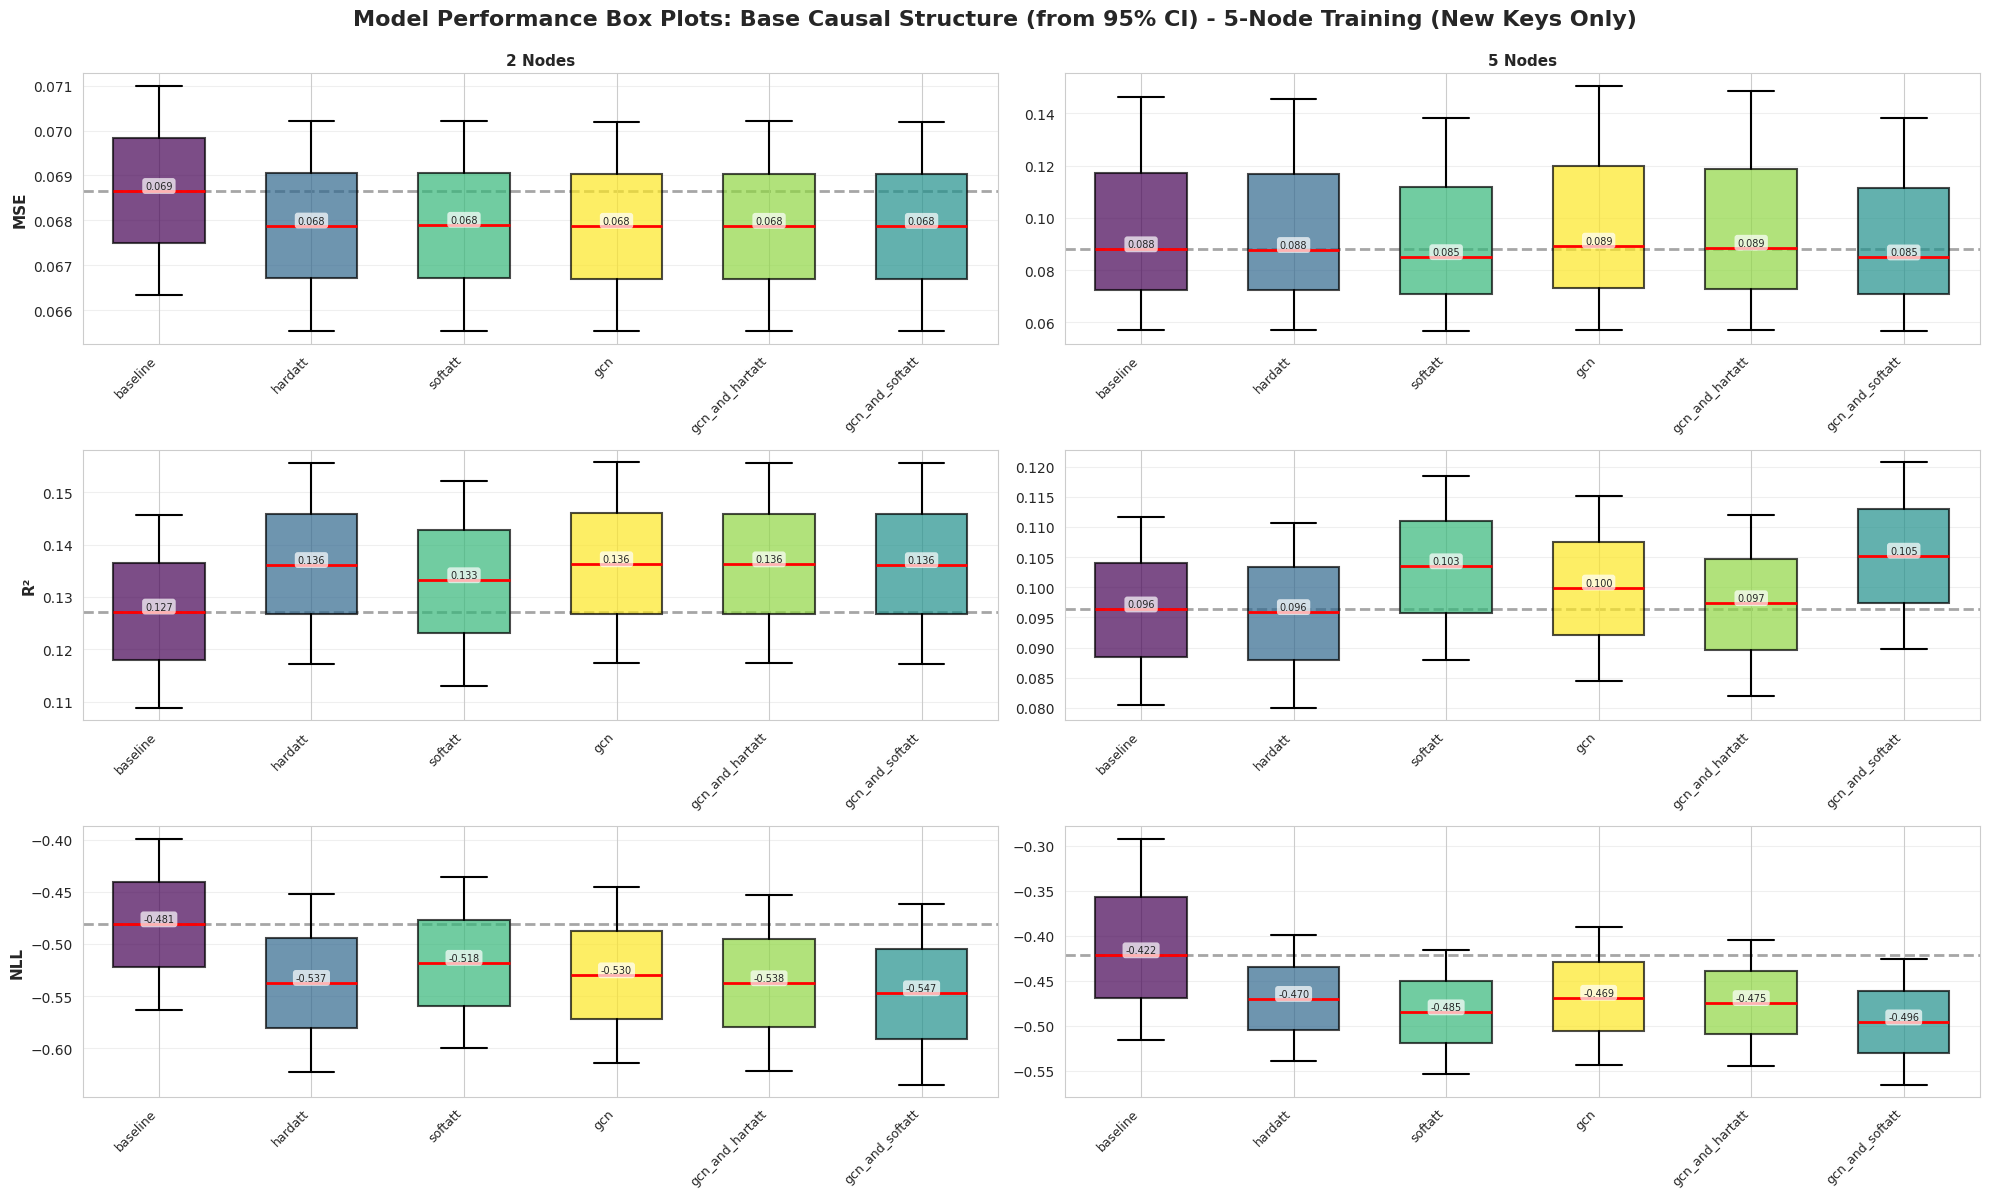

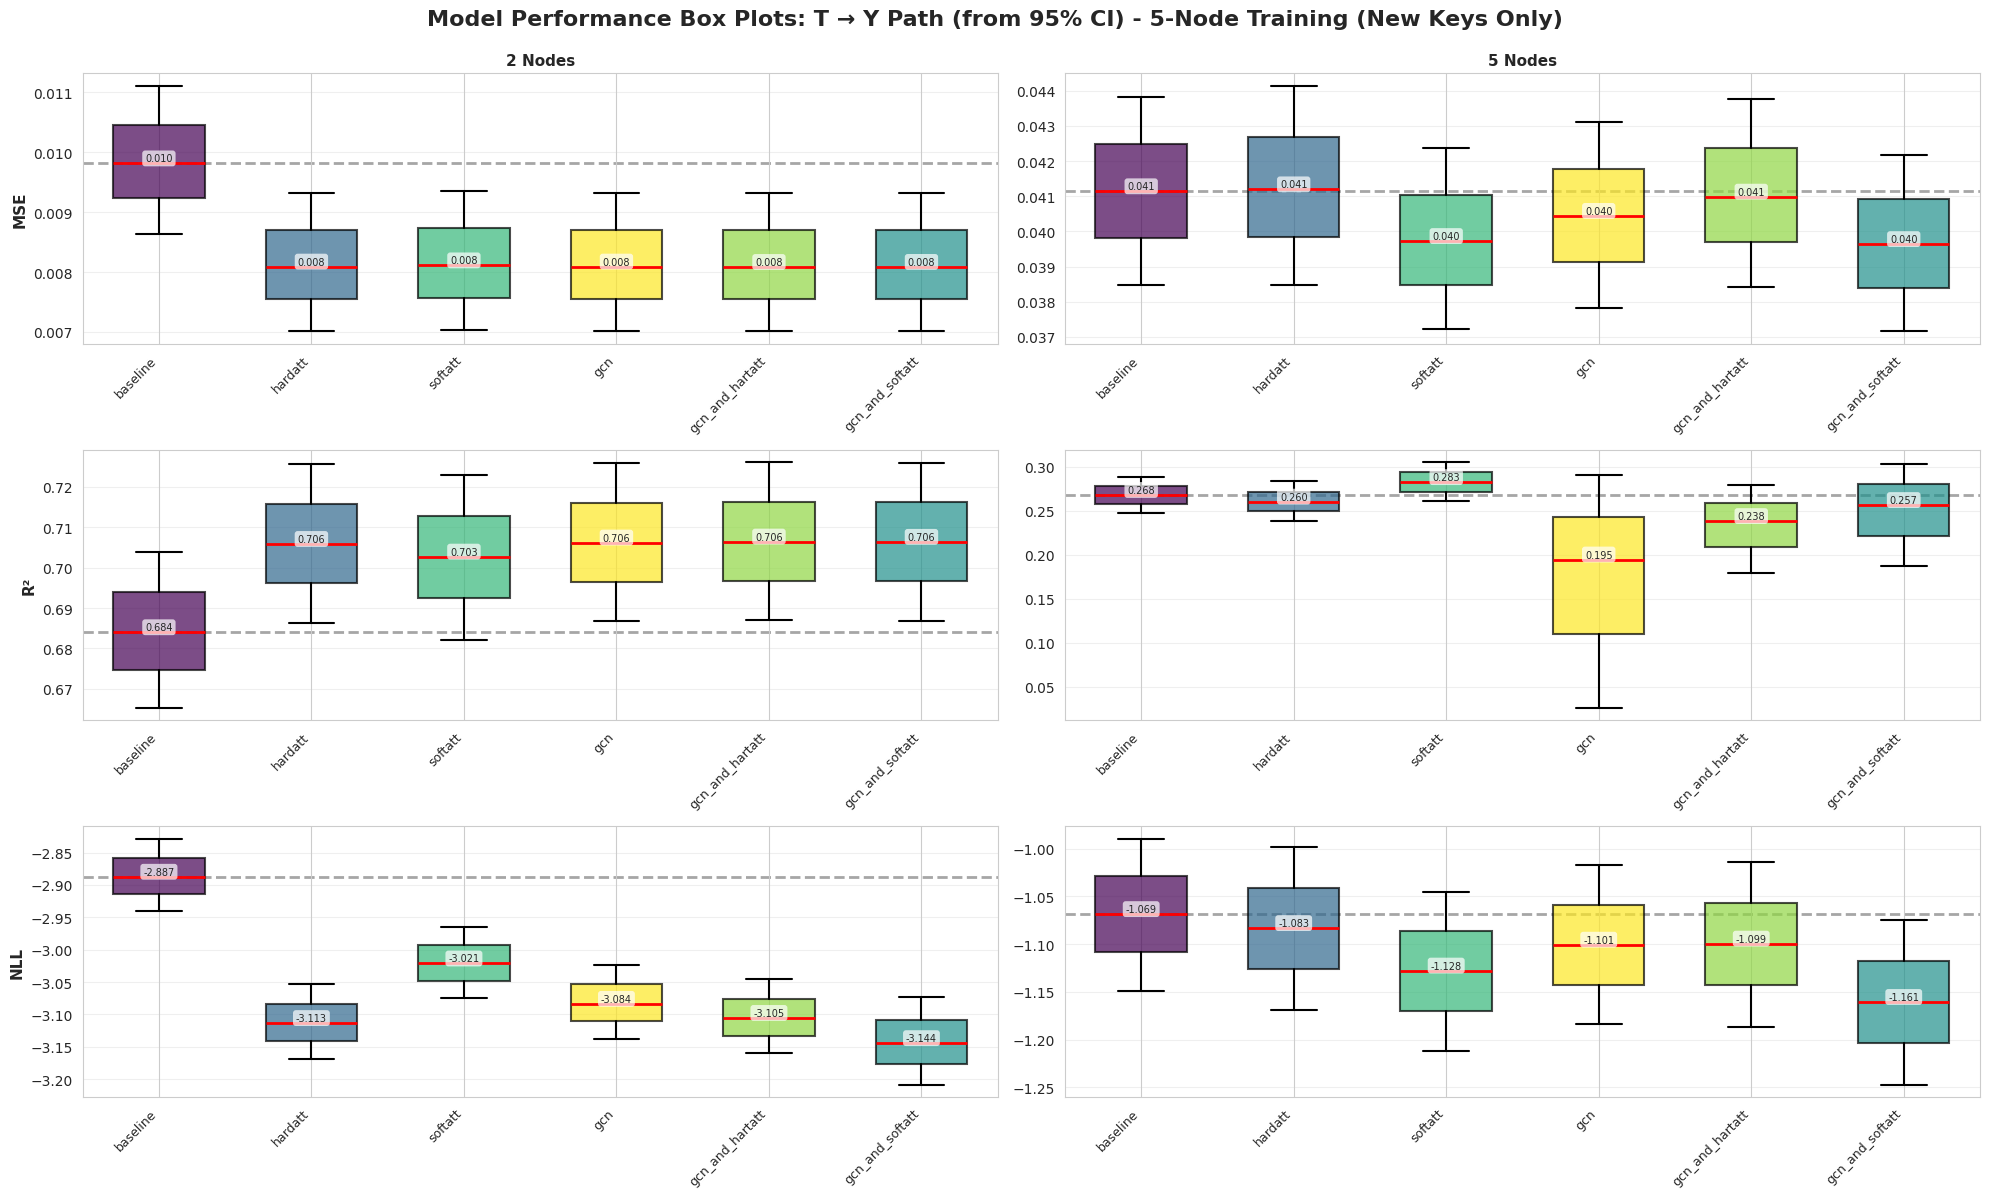

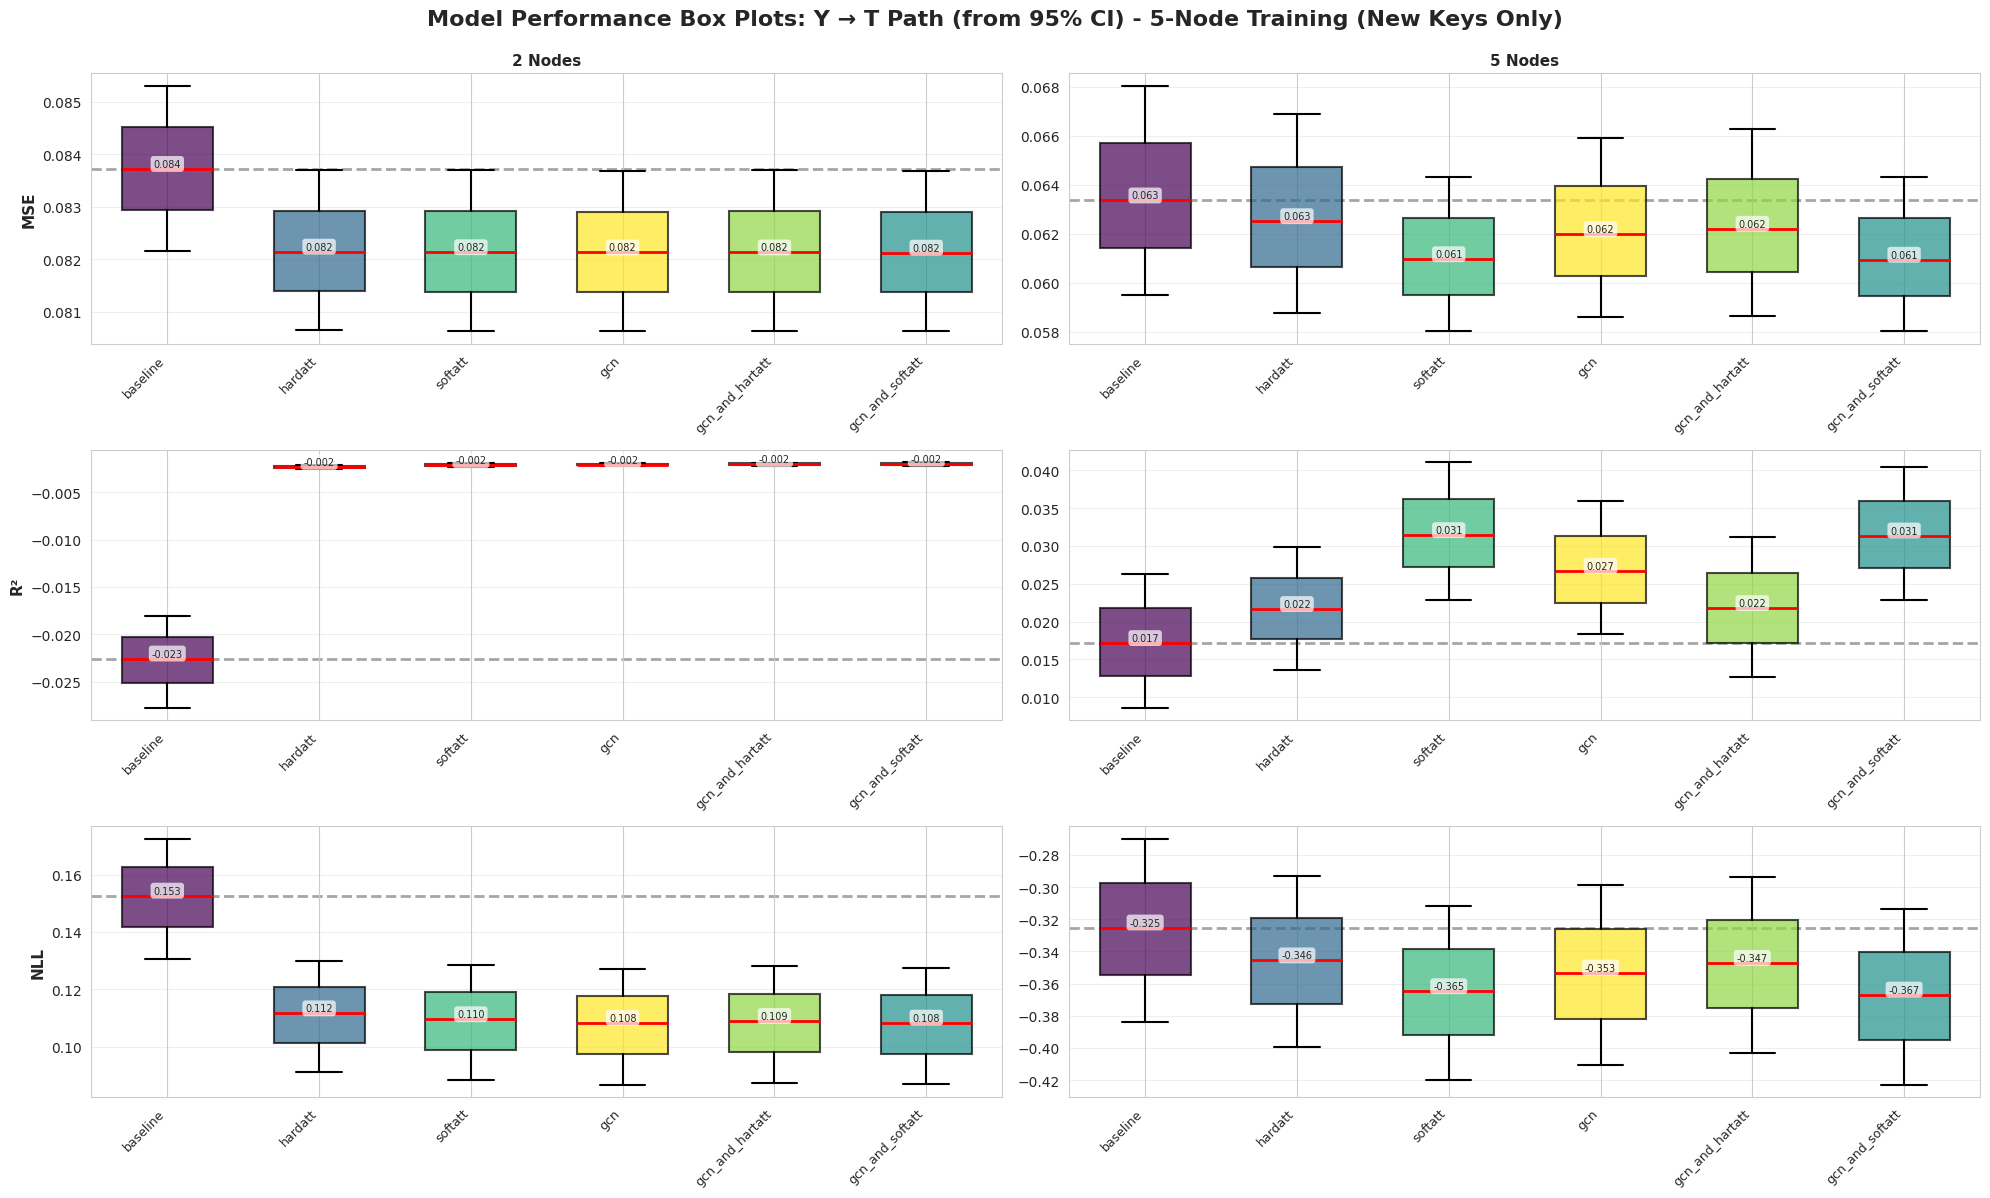

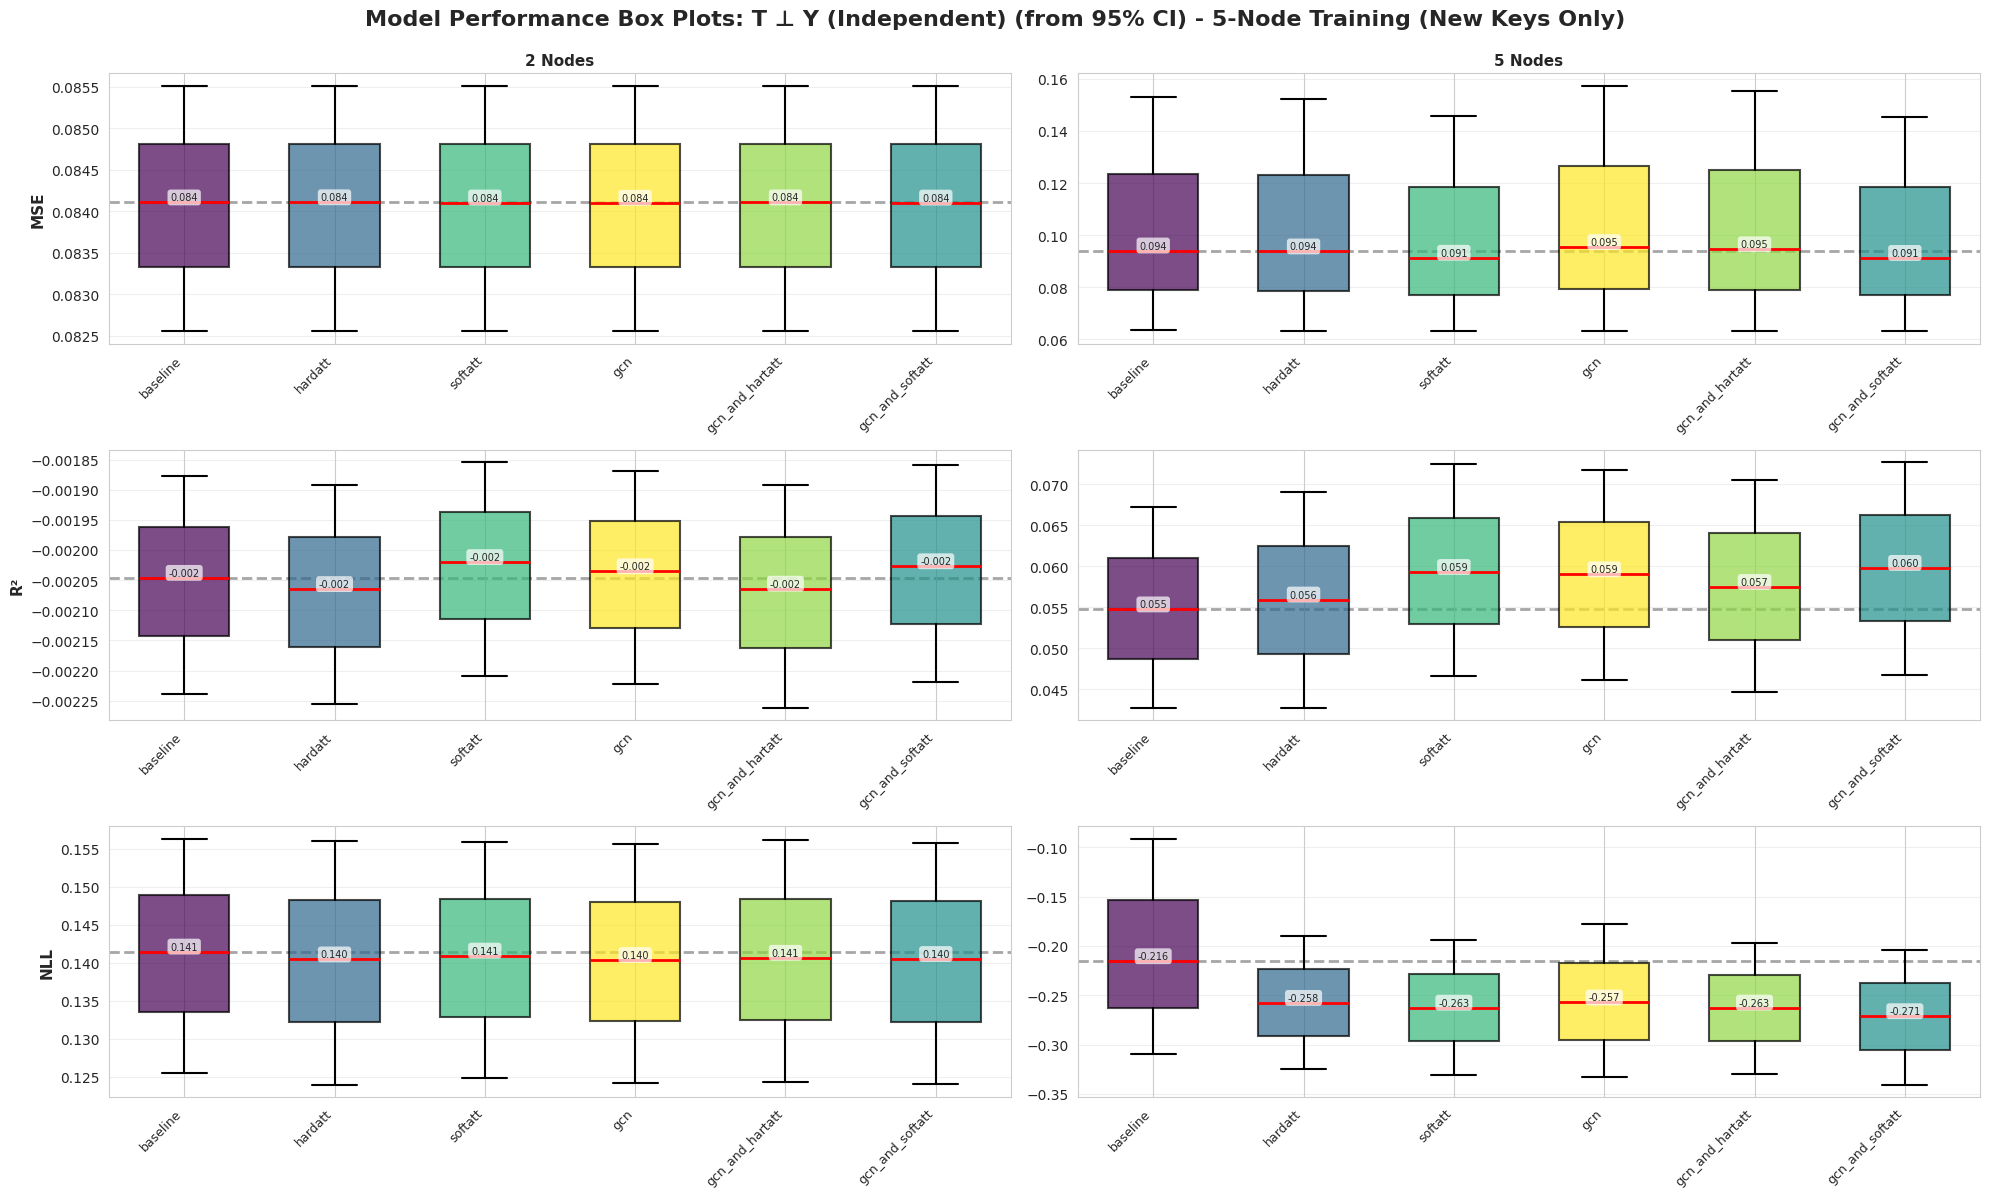

SUMMARY STATISTICS BY MODEL - 5-Node Training (Old Keys Only)

VARIANT: base

BASELINE
--------------------------------------------------------------------------------
MSE   - Mean: 0.055315 ± 0.019125
R²    - Mean: 0.046872 ± 0.054391
NLL   - Mean: -0.529741 ± 0.072375

GCN
--------------------------------------------------------------------------------
MSE   - Mean: 0.055227 ± 0.019576
R²    - Mean: 0.050422 ± 0.058517
NLL   - Mean: -0.542510 ± 0.048137

GCN_AND_HARTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.055019 ± 0.019371
R²    - Mean: 0.050504 ± 0.057327
NLL   - Mean: -0.550269 ± 0.047764

GCN_AND_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.054419 ± 0.018076
R²    - Mean: 0.050266 ± 0.060543
NLL   - Mean: -0.538400 ± 0.036172

HARDATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.054779 ± 0.019148
R²    - Mean: 

In [8]:
new_keys = [
   "lingaus_5node_benchmarked_baseline_16715905.0",
   "lingaus_5node_benchmarked_gcn_16715908.0",
    "lingaus_5node_benchmarked_gcn_and_hartatt_16715906.0",
    "lingaus_5node_benchmarked_gcn_and_softatt_16715907.0",
    "lingaus_5node_benchmarked_hardatt_16715909.0",
    "lingaus_5node_benchmarked_softatt_16715910.0",
]

# Analyze 5-node benchmarked results (only old_keys)
# Load regular benchmarked results
pattern_5node_regular = "lingaus_5node_benchmarked_*"
results_dict_regular = load_benchmark_results(checkpoint_base, pattern_5node_regular)

# Filter to only include new_keys
results_dict_filtered = {k: v for k, v in results_dict_regular.items() if k in new_keys}

print(f"\n{'='*80}")
print(f"Filtered to old_keys: {len(results_dict_filtered)} total results")
print(f"Keys included: {list(results_dict_filtered.keys())}")
print(f"{'='*80}\n")

# Create dataframe from filtered results
df_5node = create_dataframe(results_dict_filtered)
print(f"\nModels: {sorted(df_5node['model'].unique())}")
print(f"Node counts: {sorted(df_5node['node_count'].unique())}")

# Generate plots
plot_box_comparison_separate_variants(df_5node, node_counts_to_compare=[2, 5], title_suffix="5-Node Training (New Keys Only)")
print_summary_statistics(df_5node, title_suffix="5-Node Training (Old Keys Only)")

# Twenty-node-models

In [ ]:
for k in results_dict_regular.keys():
    print(k)

lingaus_20node_benchmarked_baseline_16694706.0
lingaus_20node_benchmarked_baseline_16715911.0
lingaus_20node_benchmarked_gcn_16694426.0
lingaus_20node_benchmarked_gcn_16715914.0
lingaus_20node_benchmarked_gcn_and_hartatt_16694424.0
lingaus_20node_benchmarked_gcn_and_hartatt_16715912.0
lingaus_20node_benchmarked_gcn_and_softatt_16694425.0
lingaus_20node_benchmarked_gcn_and_softatt_16715913.0
lingaus_20node_benchmarked_hardatt_16694427.0
lingaus_20node_benchmarked_hardatt_16715915.0
lingaus_20node_benchmarked_softatt_16694428.0
lingaus_20node_benchmarked_softatt_16715916.0


Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_20node_benchmarked_baseline_16693346.0/lingaus_final
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_20node_benchmarked_baseline_16694423.0/lingaus_final
Loaded: lingaus_20node_benchmarked_baseline_16694706.0 (1 variants)
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_20node_benchmarked_baseline_16715868.0/lingaus_final
Loaded: lingaus_20node_benchmarked_baseline_16715911.0 (4 variants)
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_20node_benchmarked_gcn_16693349.0/lingaus_final
Loaded: lingaus_20node_benchmarked_gcn_16694426.0 (1 variants)
Missing results dir: /fast/arikreuter/DoPFN_v2/CausalPriorFitting/experiments/FirstTests/checkpoints/lingaus_20node_benchmarked_gcn_16715871.0/lingaus_final
L

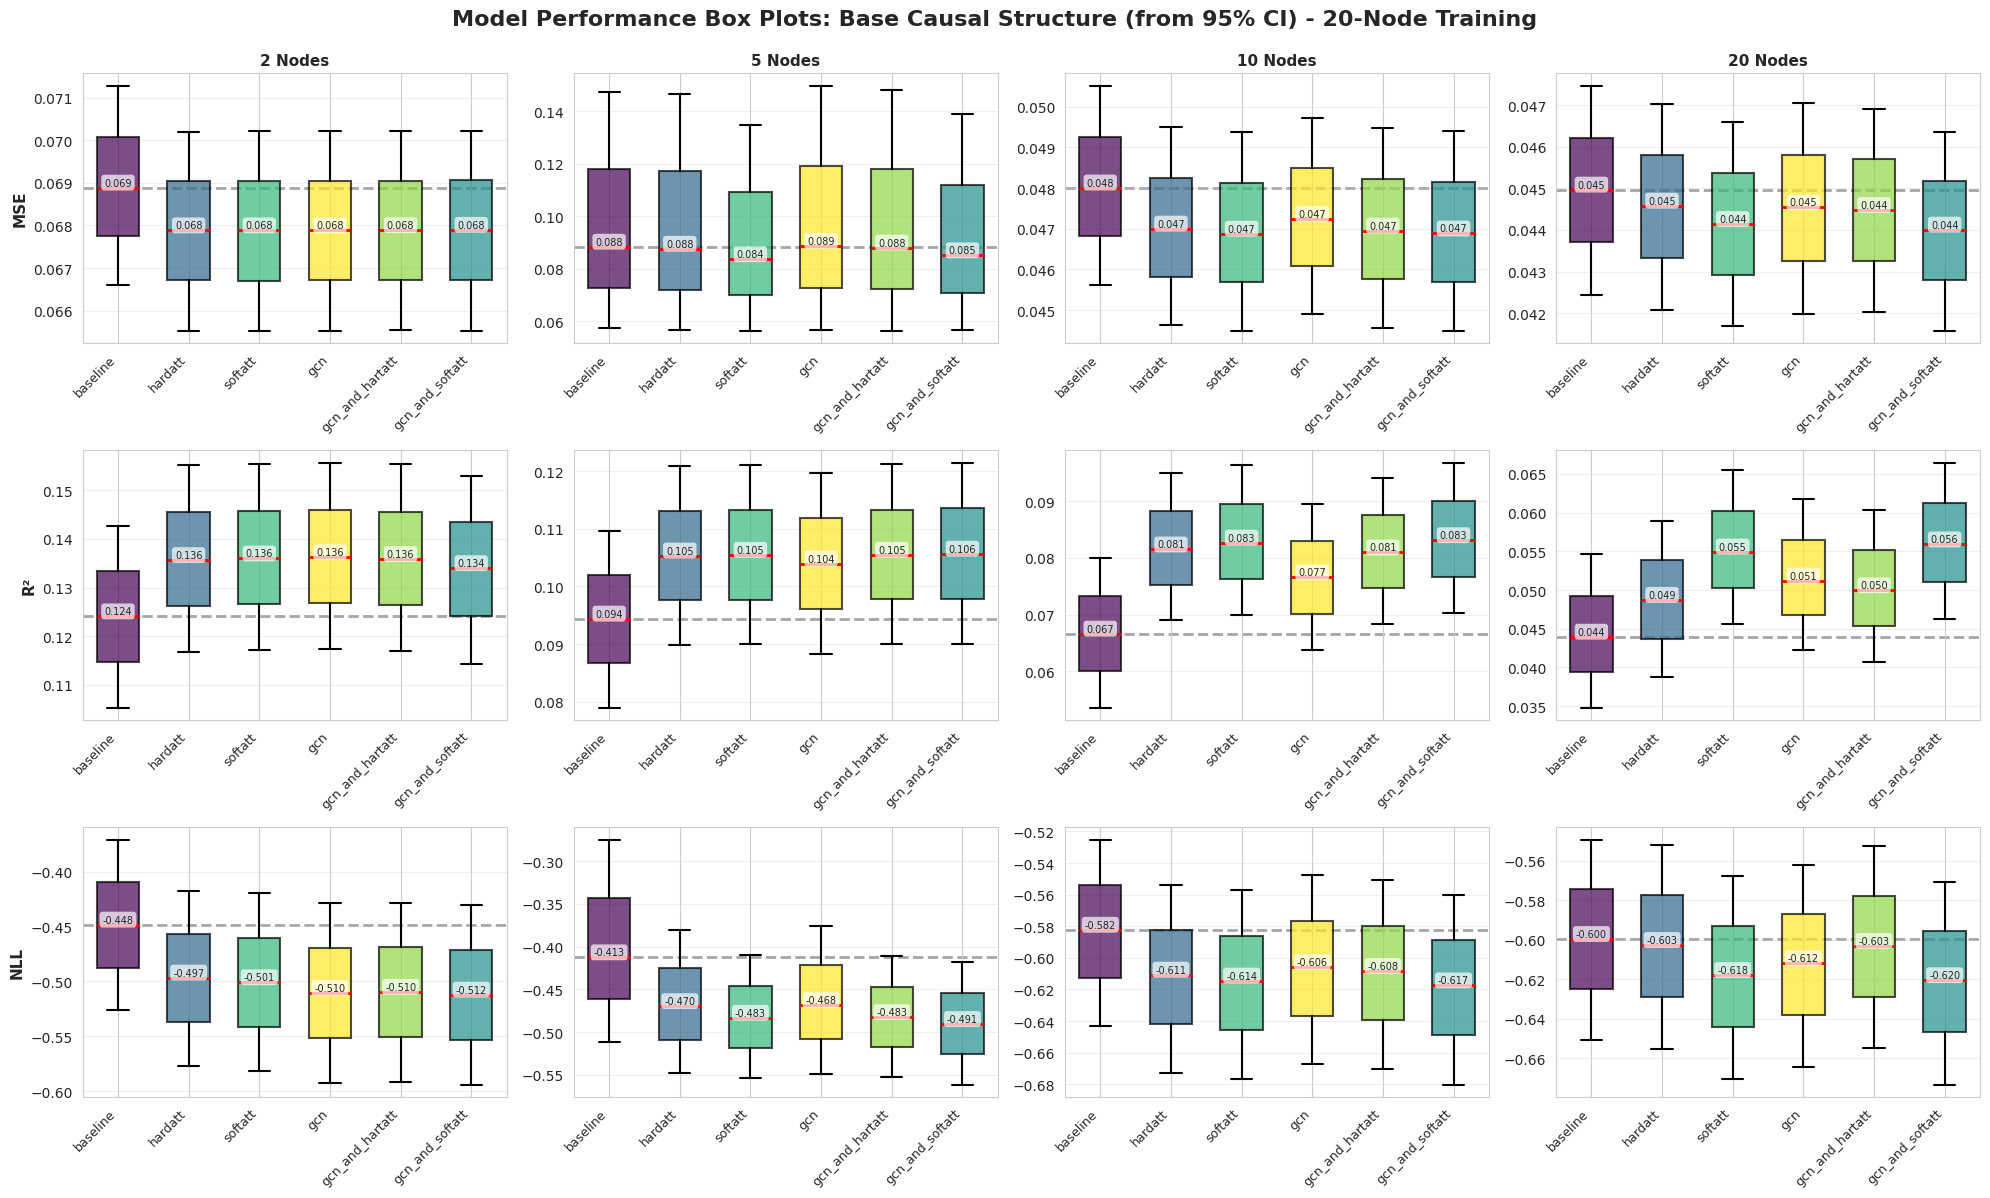

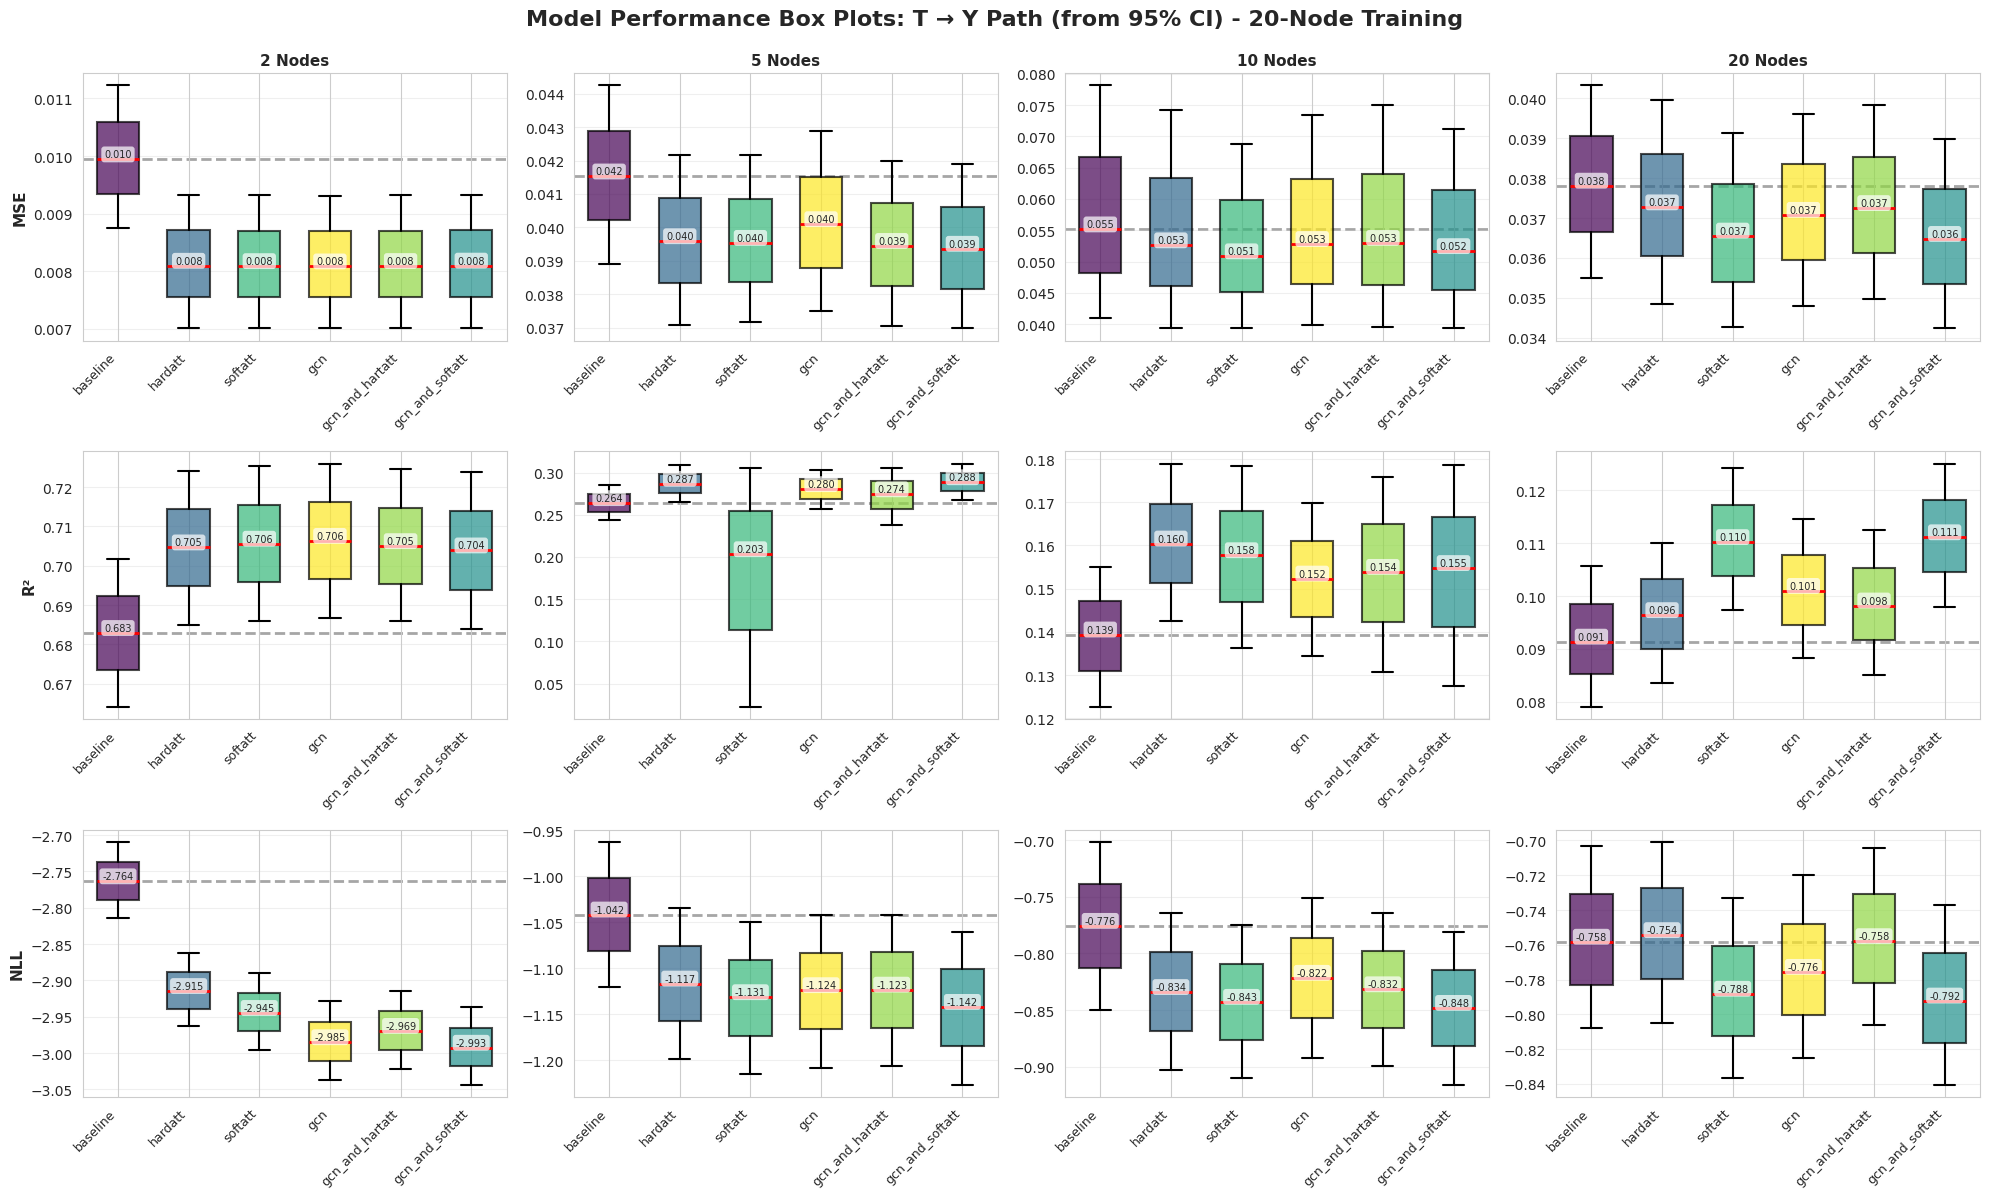

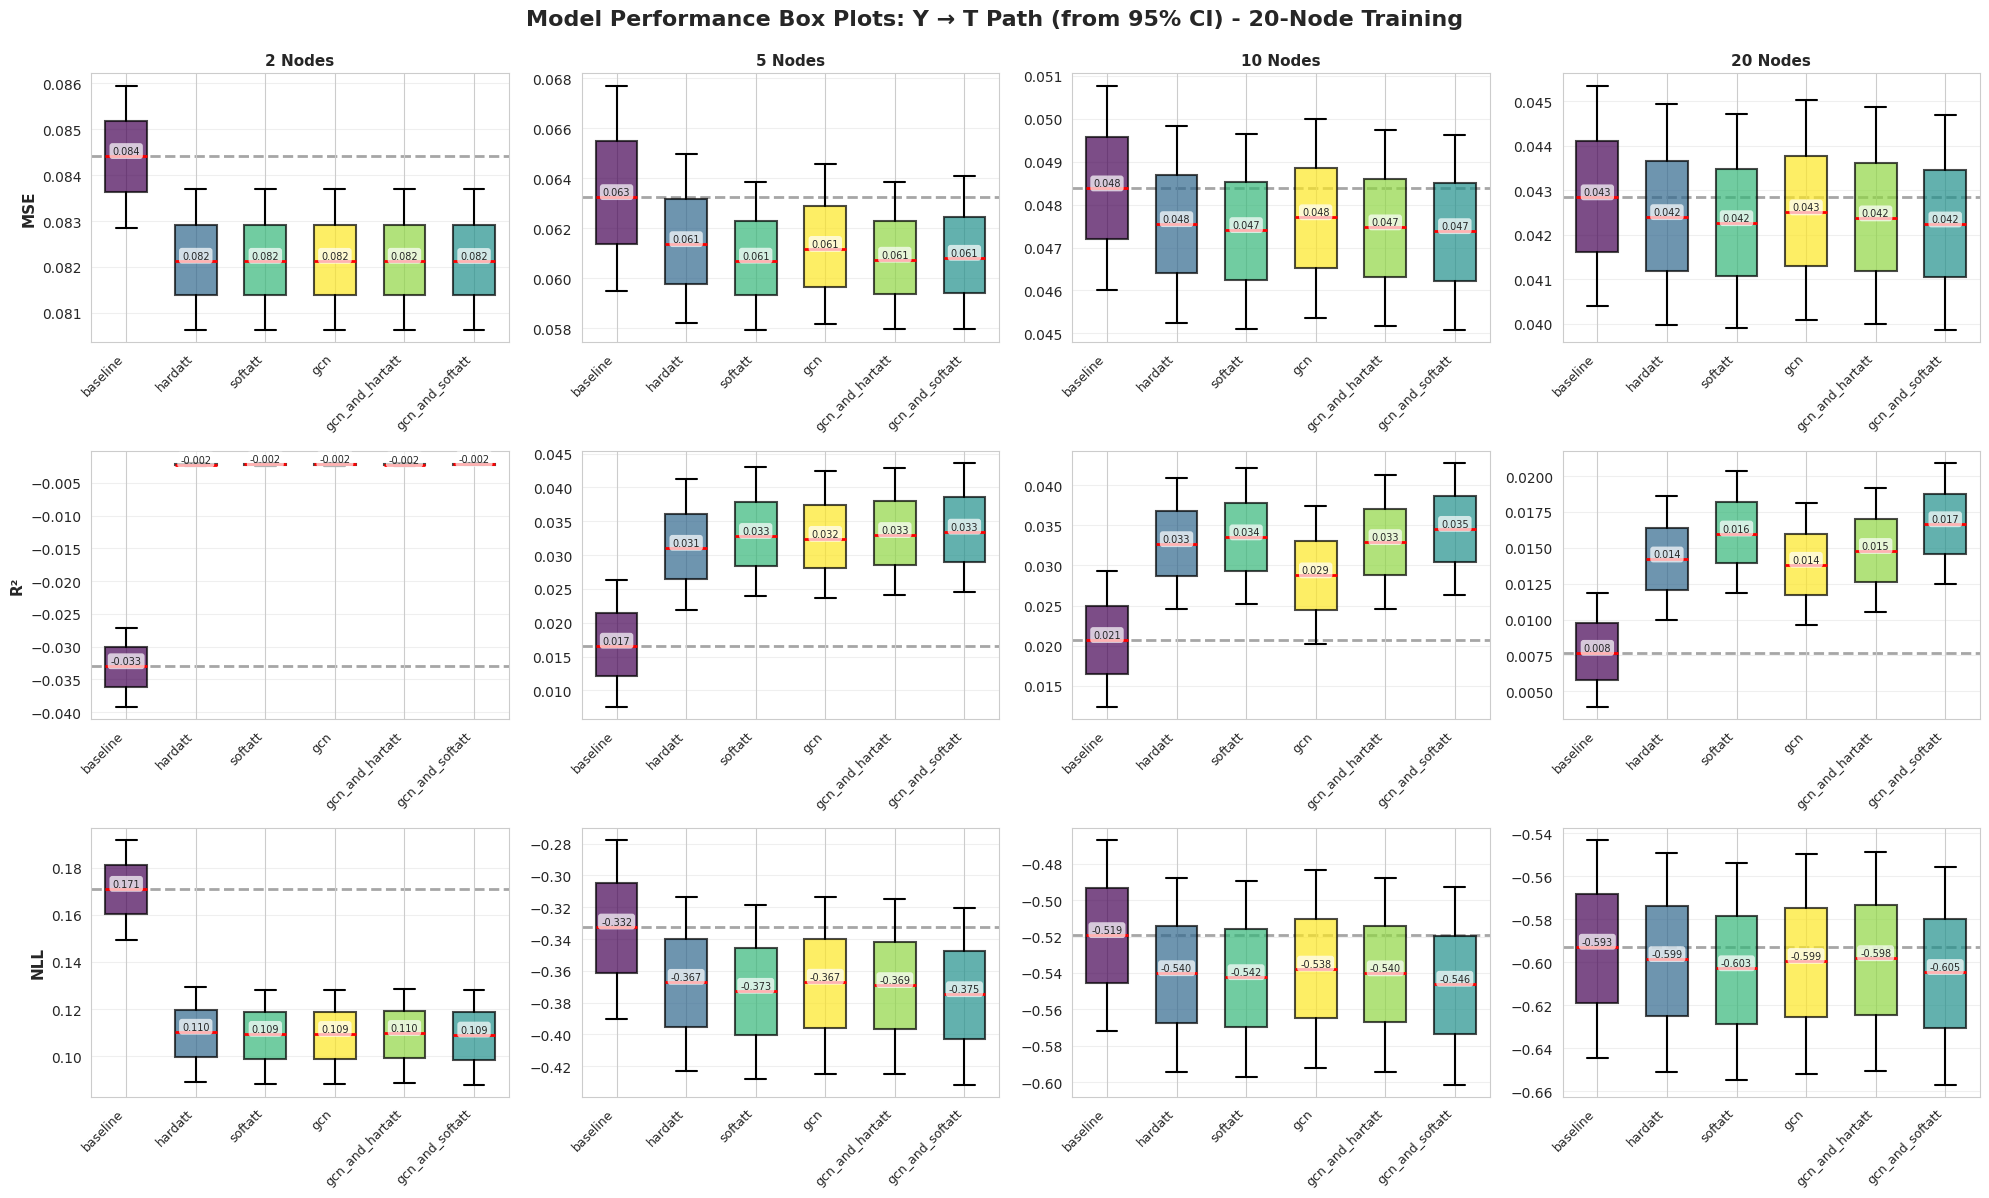

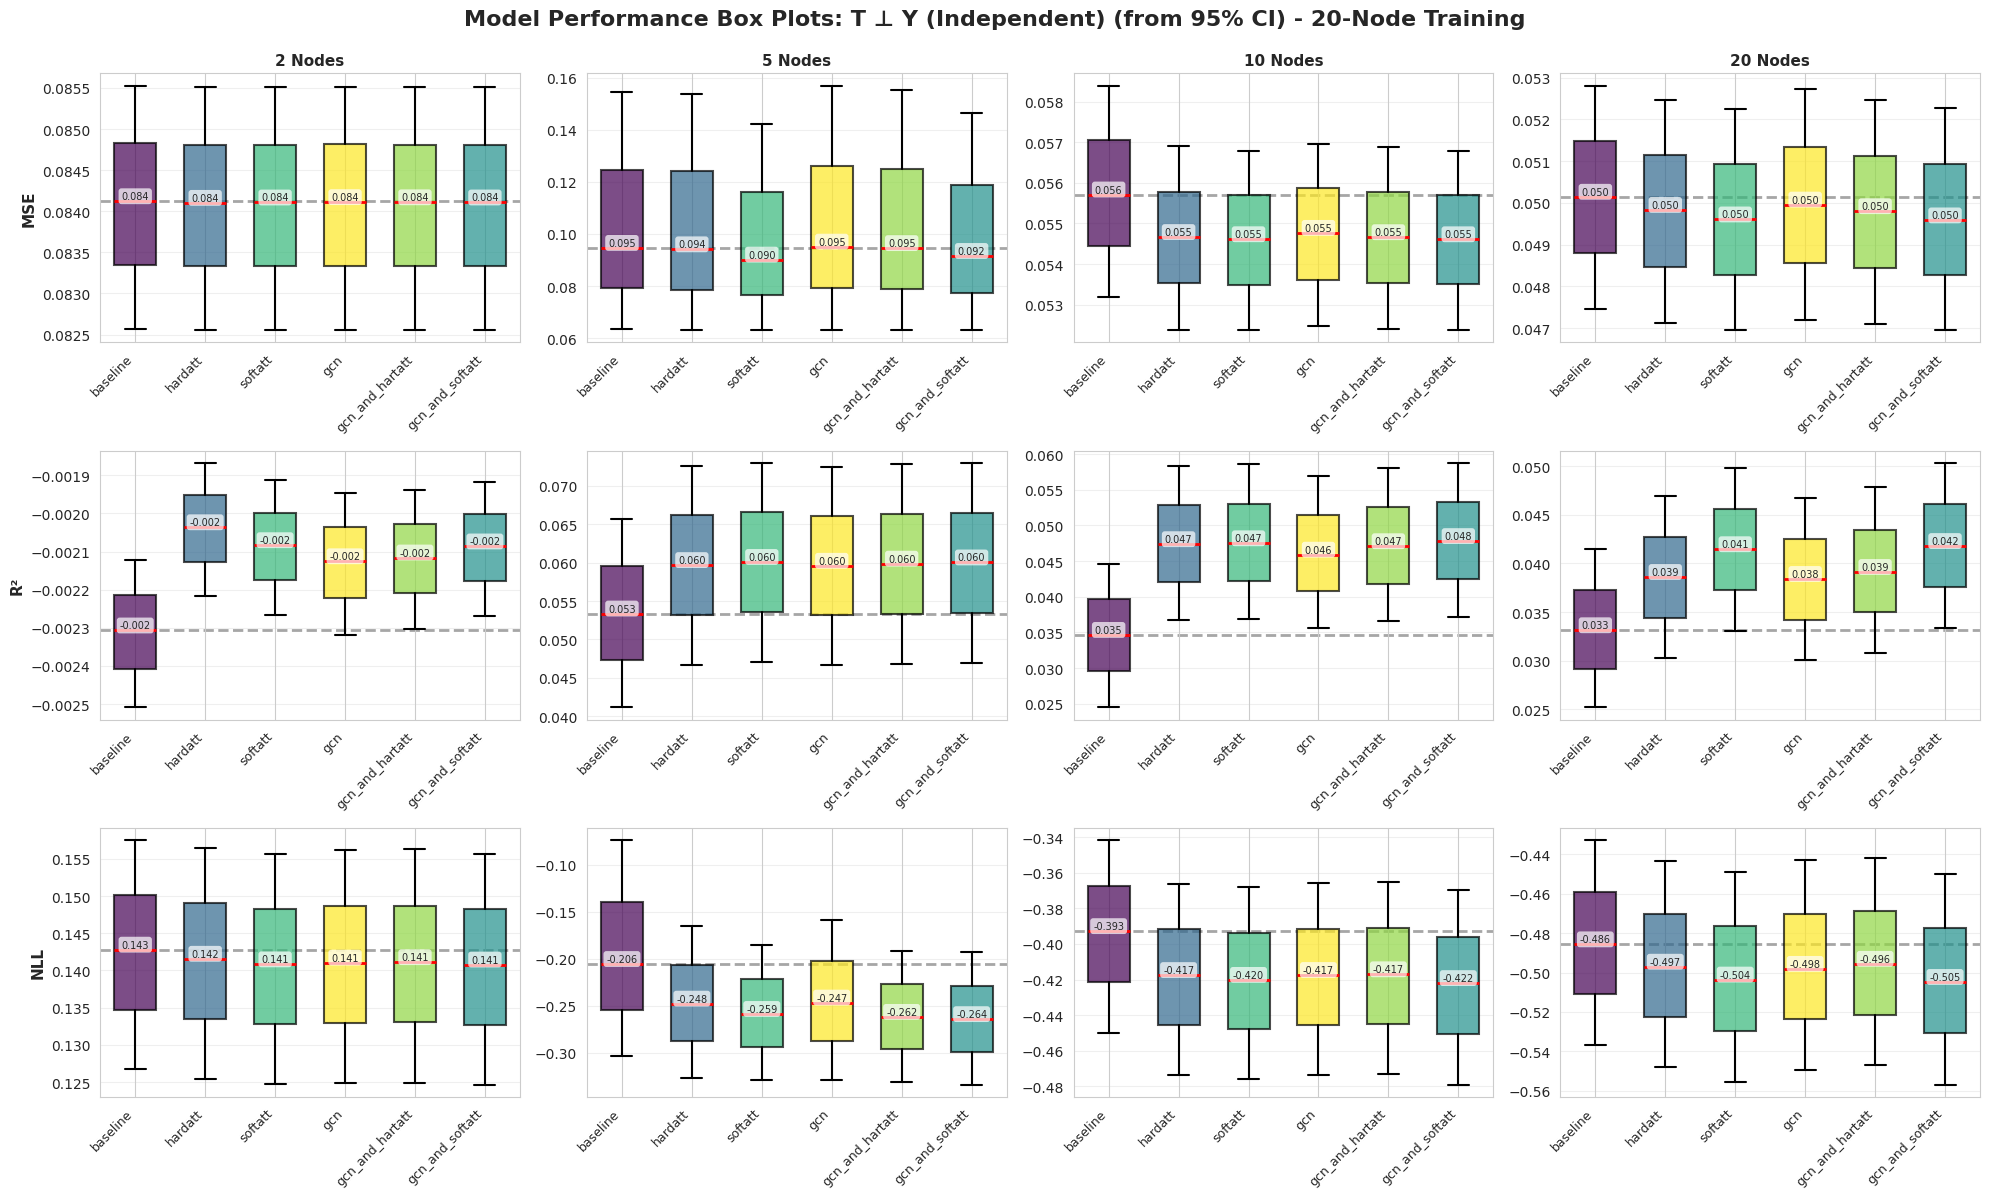

SUMMARY STATISTICS BY MODEL - 20-Node Training

VARIANT: base

BASELINE
--------------------------------------------------------------------------------
MSE   - Mean: 0.054849 ± 0.019751
R²    - Mean: 0.060651 ± 0.042968
NLL   - Mean: -0.554969 ± 0.100082

GCN
--------------------------------------------------------------------------------
MSE   - Mean: 0.054451 ± 0.019902
R²    - Mean: 0.068224 ± 0.046513
NLL   - Mean: -0.582137 ± 0.075224

GCN_AND_HARTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.054250 ± 0.019733
R²    - Mean: 0.069223 ± 0.046631
NLL   - Mean: -0.582703 ± 0.070210

GCN_AND_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.053672 ± 0.018774
R²    - Mean: 0.069508 ± 0.046810
NLL   - Mean: -0.588198 ± 0.068705

HARDATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.054183 ± 0.019573
R²    - Mean: 0.068721 ± 0.04

In [ ]:
# Analyze 20-node benchmarked results (including both regular and ancestor models)
# Load regular benchmarked results
pattern_20node_regular = "lingaus_20node_benchmarked_*"
results_dict_regular = load_benchmark_results(checkpoint_base, pattern_20node_regular)

# Load ancestor results
pattern_20node_ancestor = "lingaus_ancestor_20node_*"
results_dict_ancestor = {}

# Combine both dictionaries
results_dict_combined = {**results_dict_regular}

new_keys = [
    "lingaus_20node_benchmarked_baseline_16715911.0",
    "lingaus_20node_benchmarked_gcn_16715914.0",
    "lingaus_20node_benchmarked_gcn_and_hartatt_16715912.0",
    "lingaus_20node_benchmarked_gcn_and_softatt_16715913.0",
    "lingaus_20node_benchmarked_hardatt_16715915.0",
    "lingaus_20node_benchmarked_softatt_16715916.0",
]

results_dict_combined = {k: v for k, v in results_dict_combined.items() if k in new_keys}

print(f"\n{'='*80}")
print(f"Combined: {len(results_dict_combined)} total results (regular + ancestor)")
print(f"{'='*80}\n")

# Create dataframe from combined results
df_20node = create_dataframe(results_dict_combined)
print(f"\nModels: {sorted(df_20node['model'].unique())}")
print(f"Node counts: {sorted(df_20node['node_count'].unique())}")

# Generate plots
plot_box_comparison_separate_variants(df_20node, node_counts_to_compare=[2, 5, 10, 20], title_suffix="20-Node Training")
print_summary_statistics(df_20node, title_suffix="20-Node Training")


# Fifty-node-models

Missing JSON in: lingaus_50node_benchmarked_baseline_16693352.0
Missing JSON in: lingaus_50node_benchmarked_baseline_16694429.0
Loaded: lingaus_50node_benchmarked_baseline_16694707.0
Missing JSON in: lingaus_50node_benchmarked_gcn_16693355.0
Loaded: lingaus_50node_benchmarked_gcn_16694432.0
Missing JSON in: lingaus_50node_benchmarked_gcn_and_hartatt_16693353.0
Loaded: lingaus_50node_benchmarked_gcn_and_hartatt_16694430.0
Missing JSON in: lingaus_50node_benchmarked_gcn_and_softatt_16693354.0
Loaded: lingaus_50node_benchmarked_gcn_and_softatt_16694431.0
Missing JSON in: lingaus_50node_benchmarked_hardatt_16693356.0
Loaded: lingaus_50node_benchmarked_hardatt_16694433.0
Missing JSON in: lingaus_50node_benchmarked_softatt_16693336.0
Missing JSON in: lingaus_50node_benchmarked_softatt_16693357.0
Loaded: lingaus_50node_benchmarked_softatt_16694434.0

Total loaded: 6 results

Combined: 6 total results (regular + ancestor)

Original shape: (36, 26)
After dropping NaN rows: (36, 26)

Models: ['b

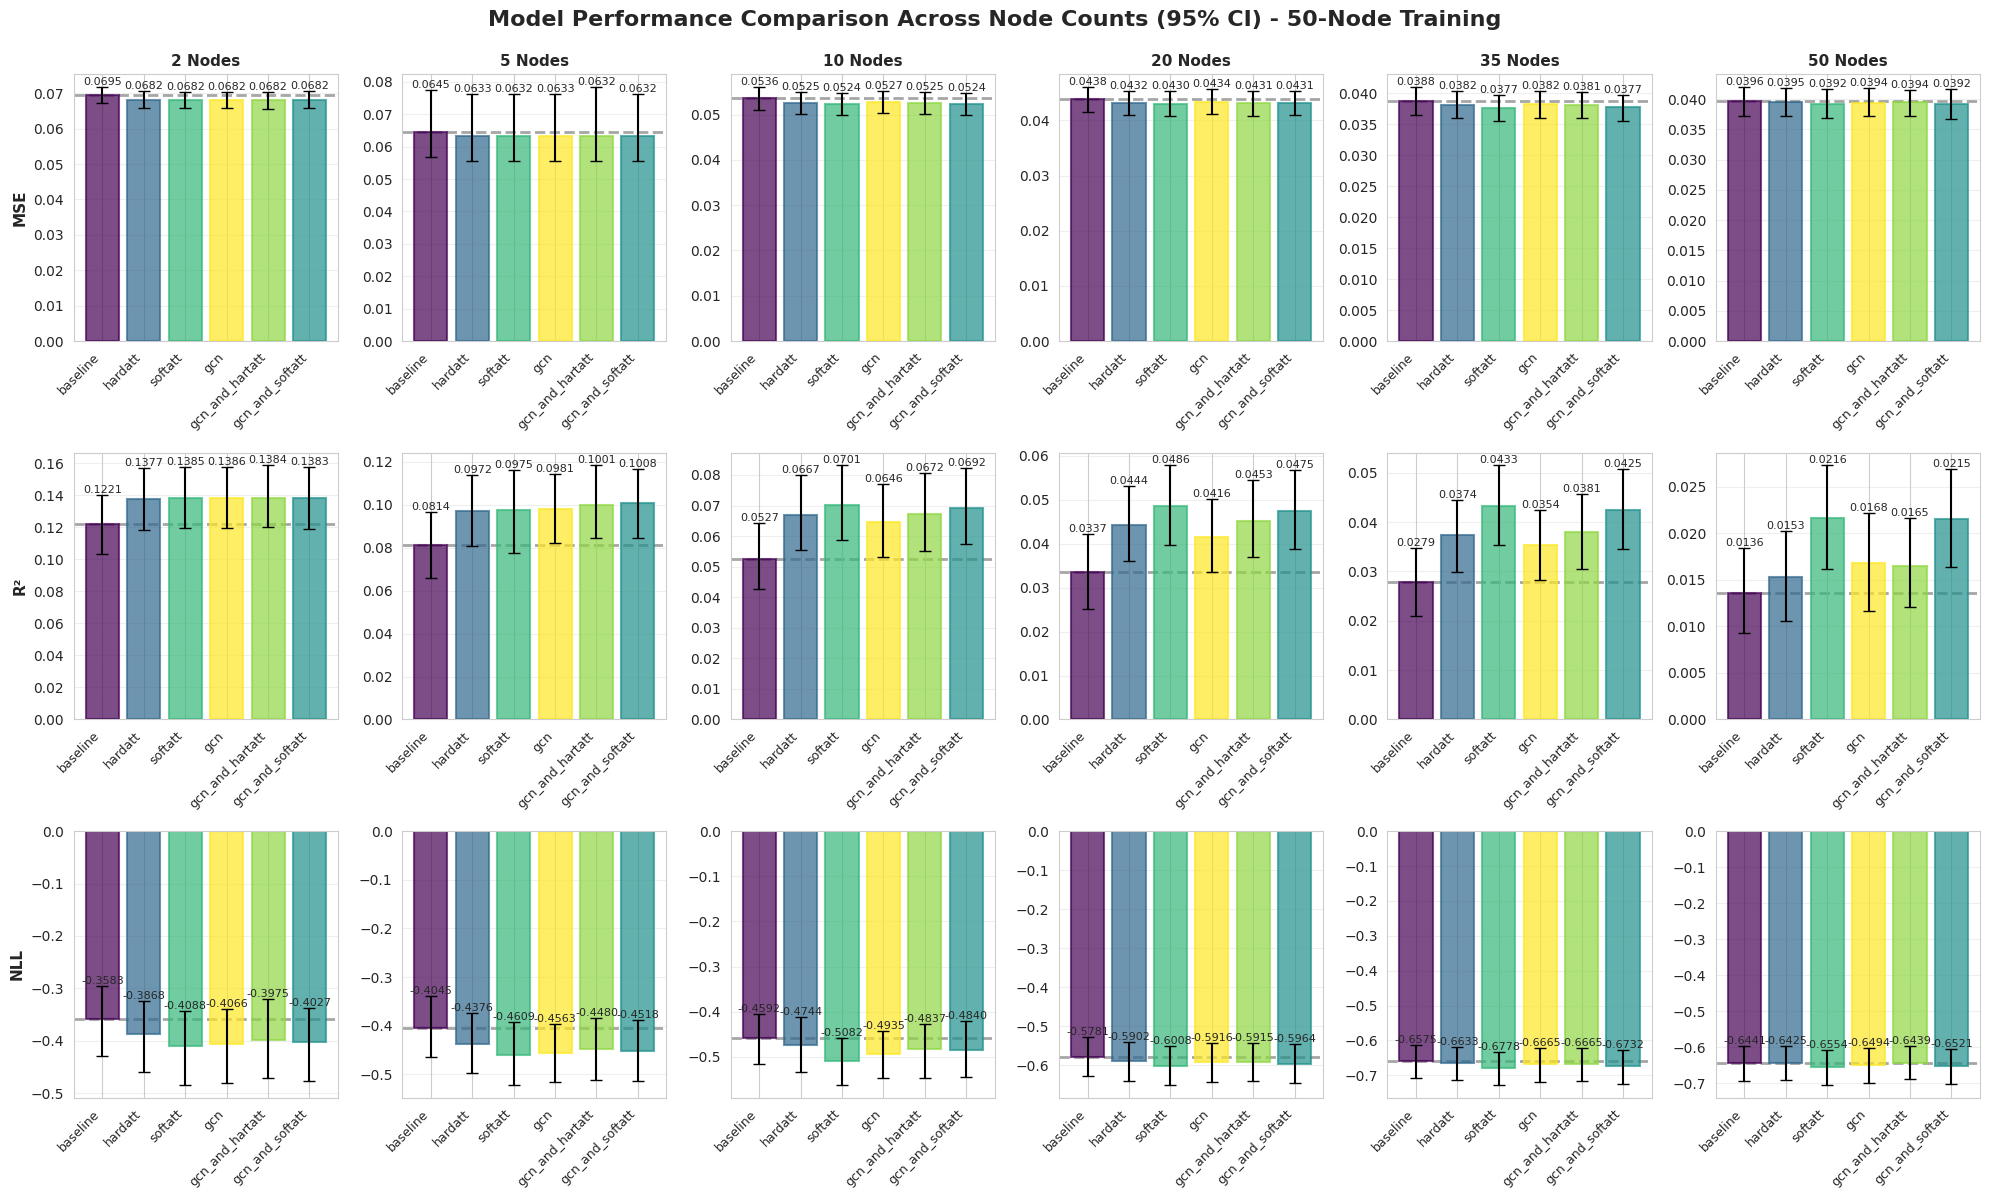

SUMMARY STATISTICS BY MODEL - 50-Node Training

BASELINE
--------------------------------------------------------------------------------
MSE   - Mean: 0.051612 ± 0.013103
R²    - Mean: 0.055227 ± 0.040284
NLL   - Mean: -0.516960 ± 0.127128

GCN
--------------------------------------------------------------------------------
MSE   - Mean: 0.050877 ± 0.012691
R²    - Mean: 0.065837 ± 0.045283
NLL   - Mean: -0.543998 ± 0.107241

GCN_AND_HARTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.050775 ± 0.012732
R²    - Mean: 0.067588 ± 0.044821
NLL   - Mean: -0.538529 ± 0.110788

GCN_AND_SOFTATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.050636 ± 0.012840
R²    - Mean: 0.069955 ± 0.042942
NLL   - Mean: -0.543366 ± 0.112391

HARDATT
--------------------------------------------------------------------------------
MSE   - Mean: 0.050804 ± 0.012716
R²    - Mean: 0.066461 ± 0.044666
NLL   - Me

In [ ]:
# Analyze 50-node benchmarked results (including both regular and ancestor models)
# Load regular benchmarked results
pattern_50node_regular = "lingaus_50node_benchmarked_*"
results_dict_regular = load_benchmark_results(checkpoint_base, pattern_50node_regular)

# Load ancestor results
pattern_50node_ancestor = "lingaus_ancestor_50node_*"
results_dict_ancestor = {}

# Combine both dictionaries
results_dict_combined = {**results_dict_regular, **results_dict_ancestor}

print(f"\n{'='*80}")
print(f"Combined: {len(results_dict_combined)} total results (regular + ancestor)")
print(f"{'='*80}\n")

# Create dataframe from combined results
df_50node = create_dataframe(results_dict_combined)
print(f"\nModels: {sorted(df_50node['model'].unique())}")
print(f"Node counts: {sorted(df_50node['node_count'].unique())}")

# Generate plots
plot_bar_comparison(df_50node, node_counts_to_compare=[2, 5, 10, 20, 35, 50], title_suffix="50-Node Training")
print_summary_statistics(df_50node, title_suffix="50-Node Training")


# Cross-Training Configuration Comparison

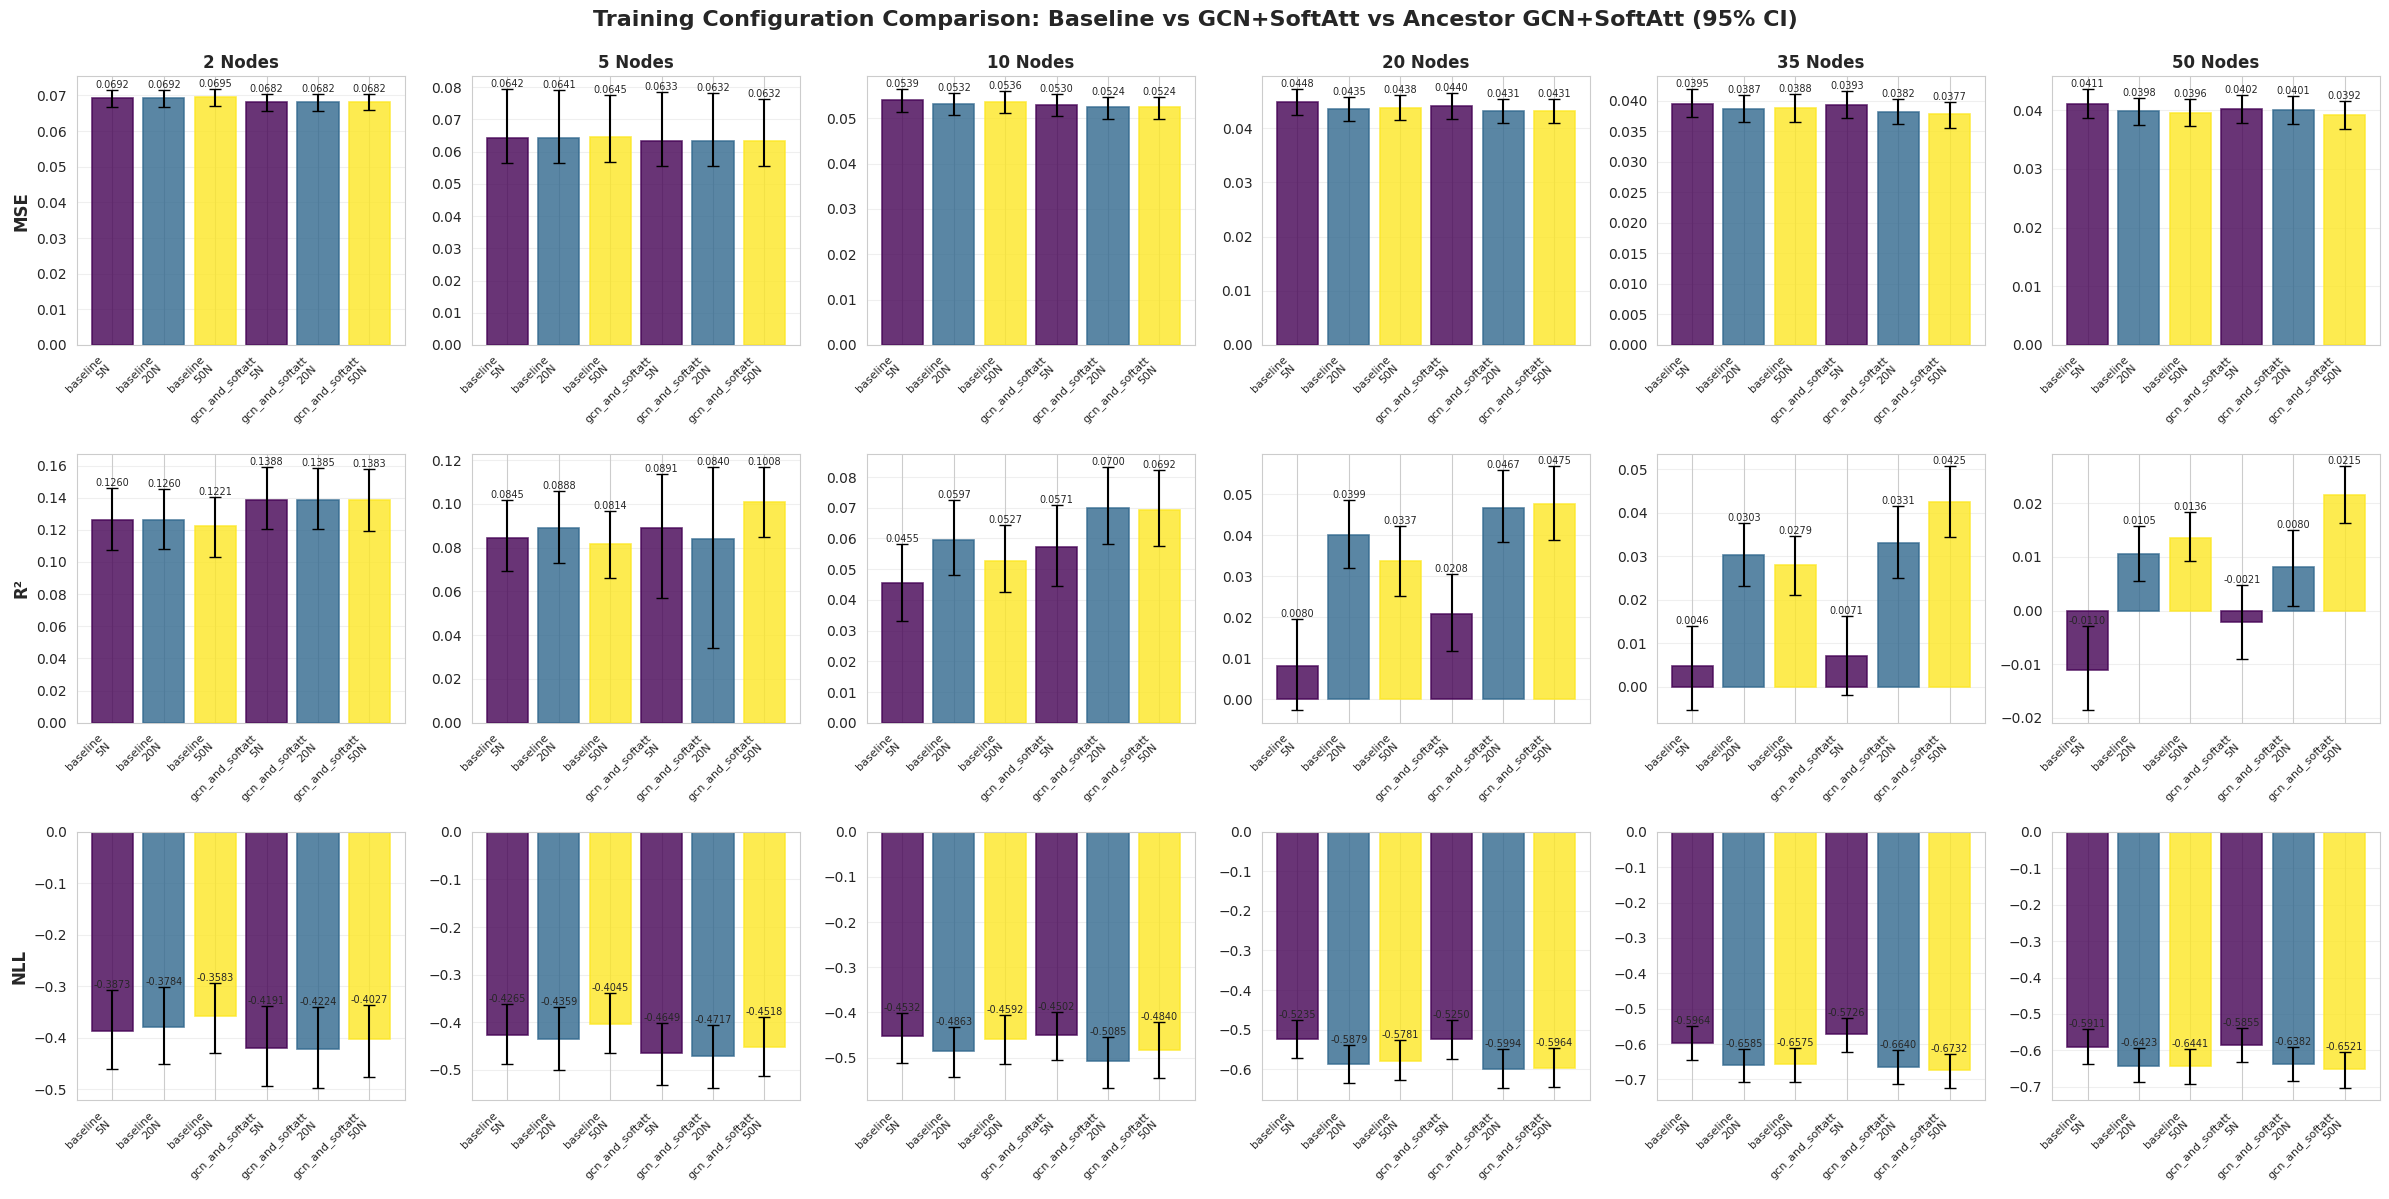

In [ ]:
# Compare gcn_and_softatt, ancestor_gcn_and_softatt, and baseline models across training configurations
def plot_training_config_comparison(df_5node, df_20node, df_50node):
    """Compare specific models across different training configurations."""
    
    # Select models to compare (including ancestor models)
    models_to_compare = ['baseline', 'gcn_and_softatt', ]
    node_counts = [2, 5, 10, 20, 35, 50]
    metrics = ['mse', 'r2', 'nll']
    metric_titles = ['MSE', 'R²', 'NLL']
    
    # Training configurations
    configs = {
        '5-Node Training': df_5node,
        '20-Node Training': df_20node,
        '50-Node Training': df_50node
    }
    
    # Color scheme for training configs
    config_colors = {
        '5-Node Training': '#440154',
        '20-Node Training': '#31688e',
        '50-Node Training': '#fde724'
    }
    
    # Create figure with subplots: 3 metrics x 6 node counts
    fig, axes = plt.subplots(len(metrics), len(node_counts), figsize=(24, 12))
    
    for metric_idx, (metric, metric_title) in enumerate(zip(metrics, metric_titles)):
        for node_idx, node_count in enumerate(node_counts):
            ax = axes[metric_idx, node_idx]
            
            # Collect data for each training config and model
            bar_data = []
            bar_labels = []
            bar_colors = []
            yerr_data = []
            
            for model in models_to_compare:
                for config_name, df in configs.items():
                    # Filter data
                    data = df[(df['model'] == model) & (df['node_count'] == node_count)]
                    
                    if len(data) > 0:
                        metric_col = f'{metric}_mean'
                        ci_lower_col = f'{metric}_mean_ci_lower'
                        ci_upper_col = f'{metric}_mean_ci_upper'
                        
                        value = data[metric_col].values[0]
                        bar_data.append(value)
                        
                        # Create label
                        label = f"{model}\n{config_name.split('-')[0]}N"
                        bar_labels.append(label)
                        bar_colors.append(config_colors[config_name])
                        
                        # Calculate error bars
                        if ci_lower_col in data.columns and ci_upper_col in data.columns:
                            ci_lower = data[ci_lower_col].values[0]
                            ci_upper = data[ci_upper_col].values[0]
                            yerr_lower = value - ci_lower
                            yerr_upper = ci_upper - value
                            yerr_data.append([yerr_lower, yerr_upper])
                        else:
                            yerr_data.append([0, 0])
            
            if bar_data:
                x_pos = np.arange(len(bar_data))
                yerr_array = np.array(yerr_data).T
                
                bars = ax.bar(x_pos, bar_data, yerr=yerr_array, capsize=4, 
                            alpha=0.8, edgecolor='black', linewidth=1.2)
                
                # Color bars
                for bar, color in zip(bars, bar_colors):
                    bar.set_color(color)
                
                # Add value labels
                for i, val in enumerate(bar_data):
                    label_y = val + yerr_array[1][i]
                    ax.text(i, label_y, f'{val:.4f}', ha='center', va='bottom', 
                           fontsize=7, rotation=0)
                
                ax.set_xticks(x_pos)
                ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=8)
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                       transform=ax.transAxes)
            
            # Labels
            if node_idx == 0:
                ax.set_ylabel(metric_title, fontsize=12, fontweight='bold')
            
            if metric_idx == 0:
                ax.set_title(f'{node_count} Nodes', fontsize=12, fontweight='bold')
            
            ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Training Configuration Comparison: Baseline vs GCN+SoftAtt vs Ancestor GCN+SoftAtt (95% CI)', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Create the comparison plot
plot_training_config_comparison(df_5node, df_20node, df_50node)